# Rearrangement Algorithm Improvement

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import pytweezer.data_manager as DataManager
import pytweezer.analysis as an
import pytweezer.phasemask as pm
from scipy.optimize import curve_fit
import time

# ==============================================================================
# 1. GLOBAL PUBLICATION STYLE SETTINGS (rcParams) - SERIF VERSION
# ==============================================================================
plt.rcParams.update({
    "text.usetex": False,              # Set to True if you have a full LaTeX distribution installed
    "font.family": "serif",            # Changed to serif
    "font.serif": ["Times New Roman", "DejaVu Serif"], # Primary and fallback serif fonts
    "mathtext.fontset": "cm",          # Renders math symbols in LaTeX's Computer Modern font
    "font.size": 9,                    
    "axes.linewidth": 1.0,             
    "axes.labelsize": 10,
    "xtick.direction": "in",           
    "ytick.direction": "in",
    "xtick.major.size": 2,             
    "ytick.major.size": 2,
    "xtick.minor.size": 1,             
    "ytick.minor.size": 1,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.top": False,                 
    "ytick.right": False,
    "legend.frameon": False,           
    "legend.fontsize": 9,
    "figure.figsize": (3.37*1.5, 2.8*1.5),     # Standard APS single column
    "figure.dpi": 300,
    "savefig.bbox": "tight"            
})

In [2]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


---
## Initial Array

--- Target Generation ---
Grid: 20x20
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 8.35e-07 | Uniformity: 63.45% | Min/Max ratio: 0.067
Iteration 010 | Mean-Squared Error: 1.25e-08 | Uniformity: 95.53% | Min/Max ratio: 0.771
Iteration 020 | Mean-Squared Error: 3.09e-09 | Uniformity: 97.78% | Min/Max ratio: 0.864
Iteration 030 | Mean-Squared Error: 1.60e-09 | Uniformity: 98.40% | Min/Max ratio: 0.904
Iteration 040 | Mean-Squared Error: 7.06e-10 | Uniformity: 98.94% | Min/Max ratio: 0.925
Iteration 050 | Mean-Squared Error: 3.75e-10 | Uniformity: 99.23% | Min/Max ratio: 0.954
Iteration 060 | Mean-Squared Error: 2.42e-10 | Uniformity: 99.38% | Min/Max ratio: 0.964
Iteration 070 | Mean-Squared Error: 1.41e-10 | Uniformity: 99.53% | Min/Max ratio: 0.969
Iteration 080 | Mean-Squared Error: 1.12e-10 | Uniformity: 99.58% | Min/Max ratio: 0.974
Iteration 090 | Mean-Squared Error: 1.64e-10 | Uniformity: 99.49% | Min/Max ratio: 0.967
Itera

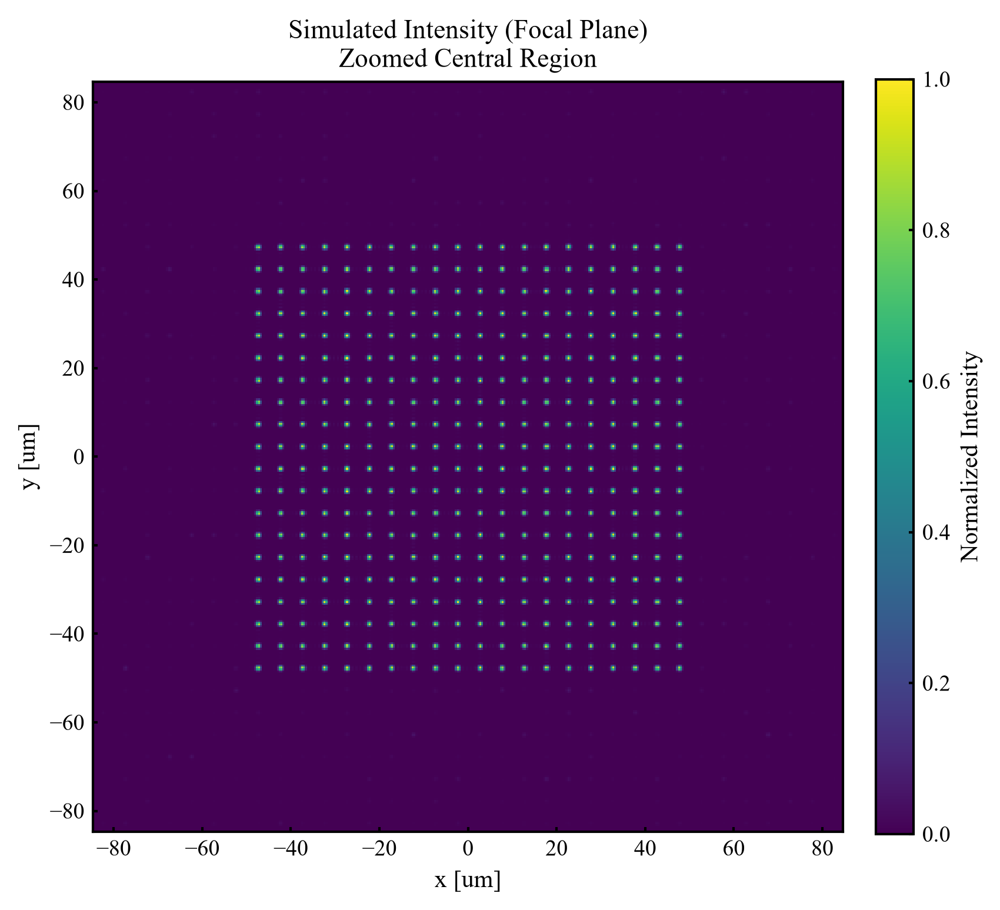

In [3]:
arr1 = (20, 20)
W1 = np.ones(arr1)
spacing_um = 5.0

w_n, theta_n, x_n, y_n = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=0.0)
terms1 = [w_n, theta_n, x_n, y_n]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)
_ = PM.simulate_focal_plane(pm_array1, Nx_pad=2048, Ny_pad=2048, zoom_pixels=100, show=True)

## Final Array

--- Target Generation ---
Grid: 14x14
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 3.99e-06 | Uniformity: 60.83% | Min/Max ratio: 0.062
Iteration 010 | Mean-Squared Error: 3.62e-08 | Uniformity: 96.27% | Min/Max ratio: 0.790
Iteration 020 | Mean-Squared Error: 4.35e-09 | Uniformity: 98.71% | Min/Max ratio: 0.934
Iteration 030 | Mean-Squared Error: 3.84e-09 | Uniformity: 98.79% | Min/Max ratio: 0.936
Iteration 040 | Mean-Squared Error: 2.13e-09 | Uniformity: 99.10% | Min/Max ratio: 0.943
Iteration 050 | Mean-Squared Error: 1.28e-09 | Uniformity: 99.30% | Min/Max ratio: 0.966
Iteration 060 | Mean-Squared Error: 5.58e-10 | Uniformity: 99.54% | Min/Max ratio: 0.975


Iteration 070 | Mean-Squared Error: 2.28e-10 | Uniformity: 99.70% | Min/Max ratio: 0.985
Iteration 080 | Mean-Squared Error: 1.31e-10 | Uniformity: 99.78% | Min/Max ratio: 0.987
Iteration 090 | Mean-Squared Error: 1.09e-10 | Uniformity: 99.79% | Min/Max ratio: 0.988
Iteration 100 | Mean-Squared Error: 1.63e-10 | Uniformity: 99.75% | Min/Max ratio: 0.987
Iteration 110 | Mean-Squared Error: 2.76e-10 | Uniformity: 99.67% | Min/Max ratio: 0.982
Iteration 120 | Mean-Squared Error: 3.97e-10 | Uniformity: 99.61% | Min/Max ratio: 0.979
Iteration 130 | Mean-Squared Error: 2.78e-10 | Uniformity: 99.67% | Min/Max ratio: 0.981
Iteration 140 | Mean-Squared Error: 1.32e-10 | Uniformity: 99.77% | Min/Max ratio: 0.988
Iteration 150 | Mean-Squared Error: 5.84e-11 | Uniformity: 99.85% | Min/Max ratio: 0.991
Iteration 160 | Mean-Squared Error: 2.90e-11 | Uniformity: 99.89% | Min/Max ratio: 0.993
Iteration 170 | Mean-Squared Error: 1.52e-11 | Uniformity: 99.92% | Min/Max ratio: 0.995
Iteration 180 | Mean-

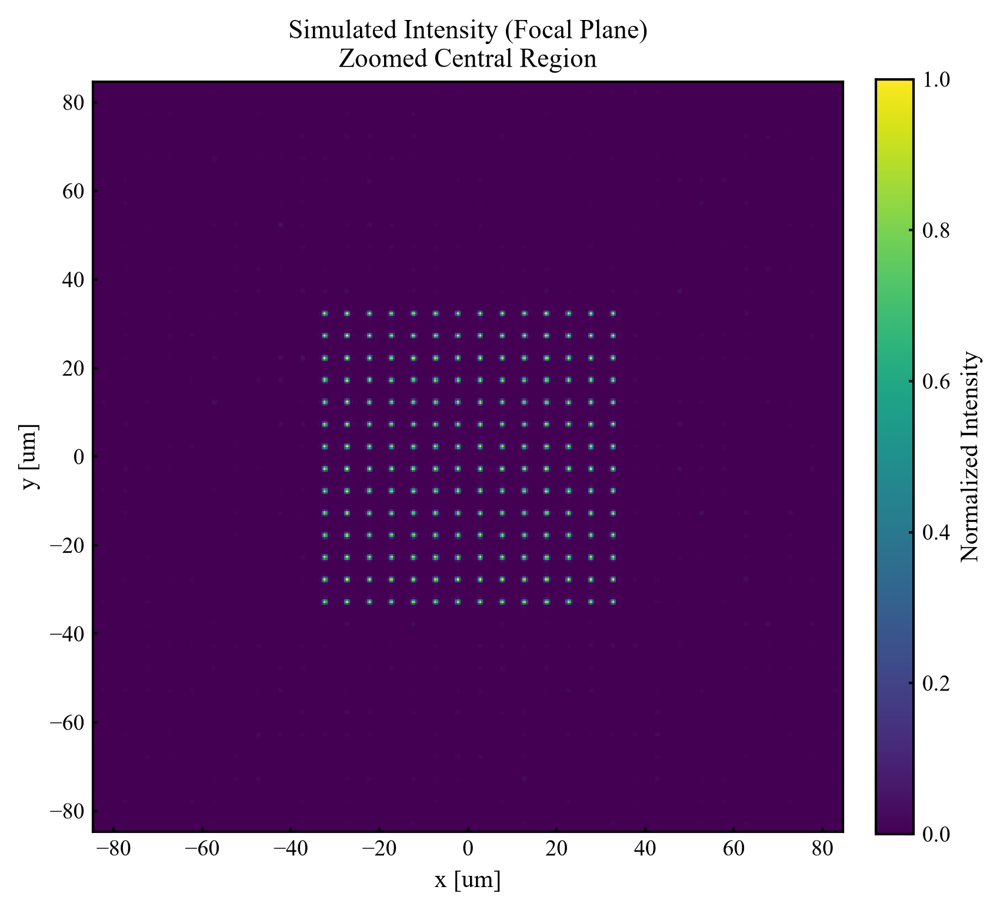

In [4]:
arr2 = (14, 14)
W2 = np.ones(arr2)
spacing_um = 5.0

w_n, theta_n, x_n, y_n = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=0.0)
terms2 = [w_n, theta_n, x_n, y_n]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=5000, damping=0.5, verbose=True)
_ = PM.simulate_focal_plane(pm_array2, Nx_pad=2048, Ny_pad=2048, zoom_pixels=100, show=True)

## Rearrangement Frame Gen Function

In [5]:
import cupy as cp
from pytweezer.phasemask import get_jv_pairing_lap

update_state_kernel = cp.ElementwiseKernel(
    'float32 dw, float32 dphi, float32 dx, float32 dy, float32 ds',
    'float32 w, float32 phi, float32 x, float32 y',
    '''
    w += dw;
    phi += dphi;
    x += dx * ds;
    y += dy * ds;
    ''',
    'update_hologram_state'
    )

def refine_phasemask(trap_terms, target_norm, iters, damping=0.5):
        """generate_phasemask plus `iters` weighted-GS updates, trap phases held fixed.

        Only the weights move; theta stays at the interpolated value. Letting theta float
        makes the iteration non-contractive, so freezing it is what allows a handful of
        iterations to help rather than wander.

        target_norm is the desired normalised intensity per site (zero on inactive sites).
        Returns the phasemask and the refined weights, for warm-starting the next frame.
        """
        w_n, theta_n, x_n, y_n = trap_terms
        w = cp.asarray(w_n, dtype=cp.float32)
        theta = cp.asarray(theta_n, dtype=cp.float32)

        X_phase = cp.exp(PM.j_k * cp.asarray(x_n, dtype=cp.float32)[:, None] * PM.x_slm[None, :])
        Y_phase = cp.exp(PM.j_k * cp.asarray(y_n, dtype=cp.float32)[:, None] * PM.y_slm[None, :])
        X_conj, Y_conj = cp.conj(X_phase), cp.conj(Y_phase)
        am_slm = PM.generate_source_amplitude().astype(cp.complex64)

        for _ in range(iters):
            pm_slm = cp.angle((Y_phase * (w * cp.exp(cp.complex64(1j) * theta))[:, None]).T @ X_phase)
            U_slm = am_slm * cp.exp(cp.complex64(1j) * pm_slm)
            I_foc = cp.abs(cp.sum(Y_conj * (U_slm @ X_conj.T).T, axis=1)) ** 2
            active = target_norm > 0
            I_norm = I_foc / I_foc[active].sum()
            # inactive sites carry target_norm == 0 and w == 0, so leave them alone
            ratio = cp.where(target_norm > 0,
                             (target_norm / cp.maximum(I_norm, cp.float32(1e-20))) ** damping,
                             cp.float32(1.0))
            w = w * ratio
            w = w / w[active].mean() 

        U_tot = (Y_phase * (w * cp.exp(cp.complex64(1j) * theta))[:, None]).T @ X_phase
        return cp.angle(U_tot).astype(cp.float32), w

def iter_rearrangement_sequence(terms1, terms2, occ_mask, d0=0.5,
                                profile="linear", refine_iters=0, refine_damping=0.5, 
                                init_refine_iters=0, init_refine_damping=0.5):

    if profile not in ("minimum_jerk", "linear"):
        raise ValueError(
            f"profile must be 'minimum_jerk' or 'linear', got {profile!r}"
        )
    w1, phi1, x1, y1 = terms1
    w2, phi2, x2, y2 = terms2
    occ_mask = cp.asarray(occ_mask)

    pos1 = cp.stack((x1, y1), axis=-1)
    pos2 = cp.stack((x2, y2), axis=-1)

    occ_indices = cp.where(occ_mask)[0]
    init = pos1[occ_indices]
    final = pos2

    init_idx, final_idx = get_jv_pairing_lap(init, final)
    moving_idx = occ_indices[init_idx]

    off_mask = cp.ones(len(pos1), dtype=bool)
    off_mask[moving_idx] = False

    pos_init = pos1[moving_idx]
    pos_final = pos2[final_idx]
    vec = pos_final - pos_init

    max_dist = cp.linalg.norm(vec, axis=1).max()
    steps_scale = 1.0 if profile == "linear" else 1.875
    n_steps = int(cp.ceil(steps_scale * max_dist / d0))

    curr_w = cp.asarray(w1, dtype=cp.float32)
    curr_phi = cp.asarray(phi1, dtype=cp.float32)
    curr_x = cp.asarray(x1, dtype=cp.float32)
    curr_y = cp.asarray(y1, dtype=cp.float32)

    tau = cp.linspace(0, 1, n_steps + 1, dtype=cp.float32)
    if profile == "linear":
        s_profile = tau
    else:
        s_profile = 10 * tau**3 - 15 * tau**4 + 6 * tau**5
    ds_profile_cpu = cp.diff(s_profile).get()

    dw = cp.zeros_like(curr_w)
    dphi = cp.zeros_like(curr_phi)
    total_dx = cp.zeros_like(curr_x)
    total_dy = cp.zeros_like(curr_y)

    w1_gpu, w2_gpu = cp.asarray(w1), cp.asarray(w2)
    phi1_gpu, phi2_gpu = cp.asarray(phi1), cp.asarray(phi2)

    dw[off_mask] = 0.0
    curr_w[off_mask] = 0.0

    target_norm = cp.zeros_like(curr_w)
    target_norm[moving_idx] = cp.float32(1.0 / len(moving_idx))
    terms_gpu = (curr_w, curr_phi, curr_x, curr_y)
    _, curr_w = refine_phasemask(terms_gpu, target_norm, init_refine_iters, init_refine_damping)

    dw[moving_idx] = (w2_gpu[final_idx] - curr_w[moving_idx]) / n_steps
    total_dx[moving_idx] = vec[:, 0].astype(cp.float32)
    total_dy[moving_idx] = vec[:, 1].astype(cp.float32)

    phase_diff = (phi2_gpu[final_idx] - phi1_gpu[moving_idx] + cp.pi) % (2 * cp.pi) - cp.pi
    dphi[moving_idx] = phase_diff / n_steps

    w_list, phi_list, x_list, y_list = [], [], [], []
    pm_slm_sequence = []
    for n in range(n_steps):
        ds = float(ds_profile_cpu[n])
        update_state_kernel(dw, dphi, total_dx, total_dy, ds, curr_w, curr_phi, curr_x, curr_y)
        terms_gpu = (curr_w, curr_phi, curr_x, curr_y)

        pm_slm, curr_w = refine_phasemask(
                            terms_gpu, target_norm, refine_iters, refine_damping)
        
        w_list.append(curr_w.get())
        phi_list.append(curr_phi.get())
        x_list.append(curr_x.get())
        y_list.append(curr_y.get())
        pm_slm_sequence.append(pm_slm.get())

    w_array = np.array(w_list)
    phi_array = np.array(phi_list)
    x_array = np.array(x_list)
    y_array = np.array(y_list)
    pm_slm_array = np.array(pm_slm_sequence)
        
    return w_array, phi_array, x_array, y_array, pm_slm_array

In [6]:
# Test occupancy mask

occupancy_mask = np.random.choice([False, True], size=arr1, p=[0.5, 0.5]).flatten()


## Situation 1: Linear Weight Interpolation

In [7]:
w_array, phi_array, x_array, y_array, pm_slm_array = iter_rearrangement_sequence(terms1, terms2, occupancy_mask, d0=0.25,
                                profile="linear", 
                                refine_iters=0, refine_damping=0.35,
                                init_refine_iters=1, init_refine_damping=0.35
                                )

In [8]:

w_on_array = []
phi_on_array = []
x_on_array = []
y_on_array = []

for i in range(w_array.shape[1]):
    if w_array[-1, i] > 0:
        w_on_array.append(w_array[:, i])
        phi_on_array.append(phi_array[:, i])
        x_on_array.append(x_array[:, i])
        y_on_array.append(y_array[:, i])

w_on_array = np.array(w_on_array).T
phi_on_array = np.array(phi_on_array).T
x_on_array = np.array(x_on_array).T
y_on_array = np.array(y_on_array).T

I_foc_array_lpi_0 = np.zeros_like(w_on_array)
phi_foc_array_lpi_0 = np.zeros_like(phi_on_array)

for i in range(pm_slm_array.shape[0]):
    pm_slm = pm_slm_array[i]
    x_n = x_on_array[i]
    y_n = y_on_array[i]
    I_foc, phi_foc = PM.evaluate_traps(pm_slm, x_n, y_n)
    I_foc_array_lpi_0[i] = I_foc / I_foc.mean()
    phi_foc_array_lpi_0[i] = phi_foc

#### Intensity Drift

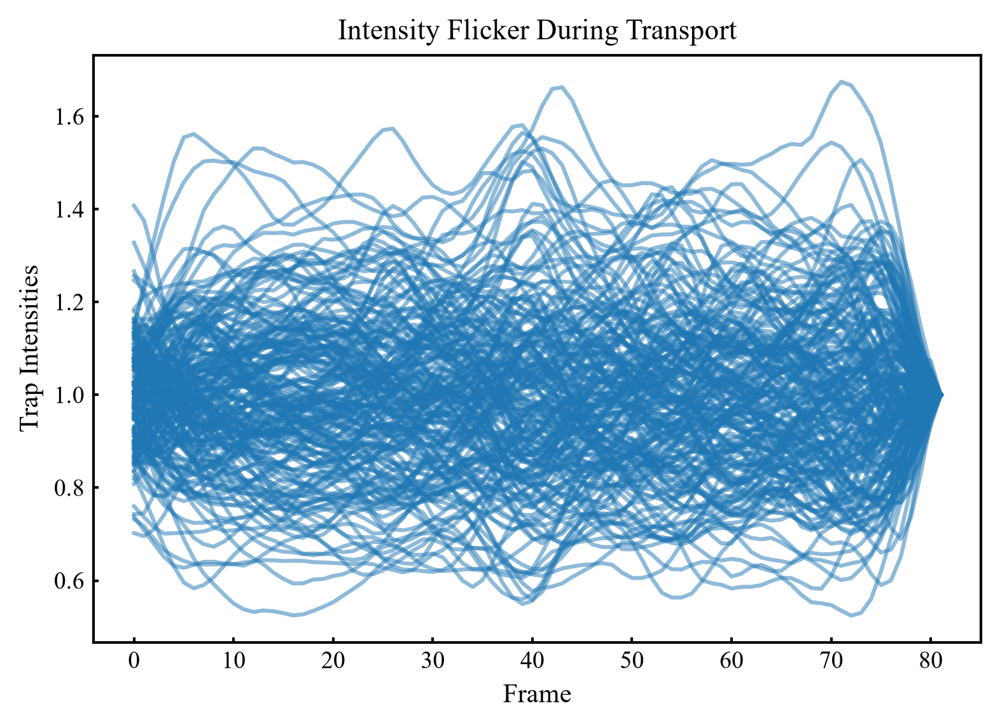

Standard deviation of trap intensities (LPI): 0.1046 (mean), 0.2640 (max), 0.0380 (min)


In [10]:
plt.figure(figsize=(6, 4))
for n in range(phi_foc_array_lpi_0.shape[1]):
    plt.plot(np.arange(I_foc_array_lpi_0.shape[0]-1), I_foc_array_lpi_0[1:, n]/np.mean(I_foc_array_lpi_0[-1, :]), alpha=0.5, color='C0')
                
plt.xlabel("Frame")
plt.ylabel("Trap Intensities")
plt.title(f"Intensity Flicker During Transport")
plt.show()

std = np.std(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]), axis=0)
print(f"Standard deviation of trap intensities (LPI): {std.mean():.4f} (mean), {std.max():.4f} (max), {std.min():.4f} (min)")

### Phase Flicker

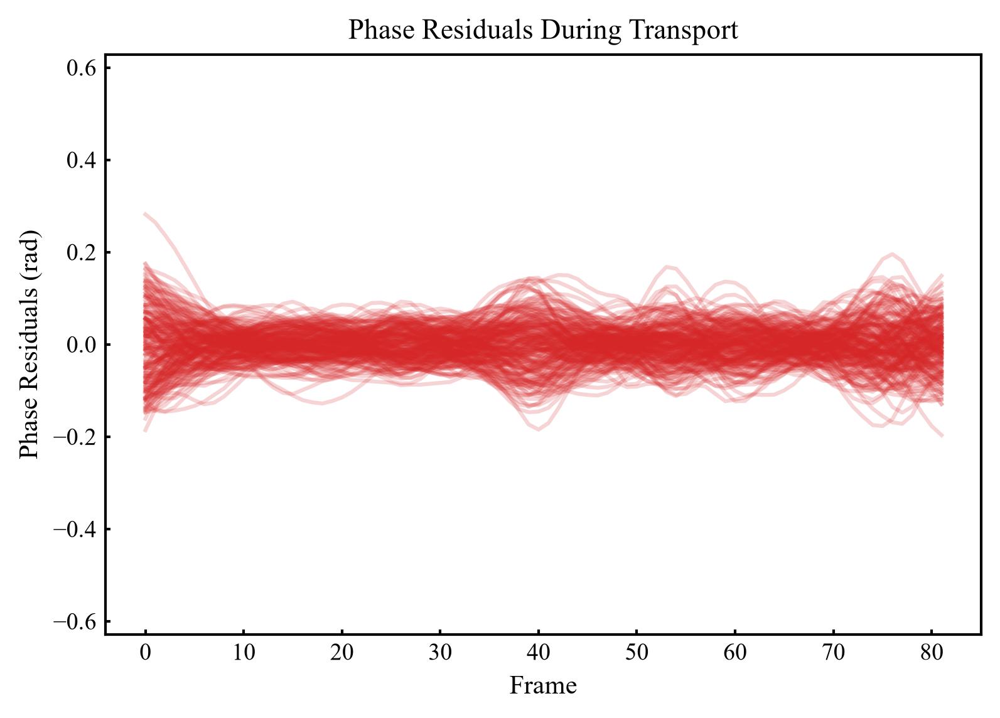

Standard deviation of phase residuals (LPI): 0.0425 rad


In [11]:
from scipy.optimize import curve_fit

plt.figure(figsize=(6, 4))
residuals_list = []

lin_fit = lambda x, m, b: m * x + b
for n in range(phi_foc_array_lpi_0.shape[1]):
    x = np.arange(phi_foc_array_lpi_0.shape[0]-1)
    y = np.unwrap(phi_foc_array_lpi_0[1:, n])
    popt, pcov = curve_fit(lin_fit, x, y)
    y_fit = lin_fit(x, *popt)
    residuals = y - y_fit
    #plt.plot(x, y, alpha=0.5, color='C0')
    #plt.plot(x, y_fit, alpha=0.8, color='C1')
    plt.plot(x, residuals, alpha=0.2, color='C3')
    residuals_list.append(residuals)

plt.ylim(-np.pi/5, np.pi/5)
plt.xlabel("Frame")
plt.ylabel("Phase Residuals (rad)")
plt.title(f"Phase Residuals During Transport")
plt.show()

residuals_array = np.array(residuals_list).flatten()
std_residuals = np.std(residuals_array)
print(f"Standard deviation of phase residuals (LPI): {std_residuals:.4f} rad")

## Situation 2: Single Iteration Weight Equalisation

In [12]:
w_array, phi_array, x_array, y_array, pm_slm_array = iter_rearrangement_sequence(terms1, terms2, occupancy_mask, d0=0.25,
                                profile="linear", 
                                refine_iters=1, refine_damping=0.35,
                                init_refine_iters=1, init_refine_damping=0.35
                                )

In [13]:
w0, phi0, x0, y0 = terms1
w0, phi0, x0, y0 = w0.get(), phi0.get(), x0.get(), y0.get()
pm_slm_0 = pm_array1.get()

w_on_array = []
phi_on_array = []
x_on_array = []
y_on_array = []

for i in range(w_array.shape[1]):
    if w_array[-1, i] > 0:
        w_on_array.append(w_array[:, i])
        phi_on_array.append(phi_array[:, i])
        x_on_array.append(x_array[:, i])
        y_on_array.append(y_array[:, i])

w_on_array = np.array(w_on_array).T
phi_on_array = np.array(phi_on_array).T
x_on_array = np.array(x_on_array).T
y_on_array = np.array(y_on_array).T

I_foc_array_lpi_1 = np.zeros_like(w_on_array)
phi_foc_array_lpi_1 = np.zeros_like(phi_on_array)
for i in range(pm_slm_array.shape[0]):
    pm_slm = pm_slm_array[i]
    x_n = x_on_array[i]
    y_n = y_on_array[i]
    I_foc, phi_foc = PM.evaluate_traps(pm_slm, x_n, y_n)
    I_foc_array_lpi_1[i] = I_foc / I_foc.mean()
    phi_foc_array_lpi_1[i] = phi_foc

#### Intensity Drift

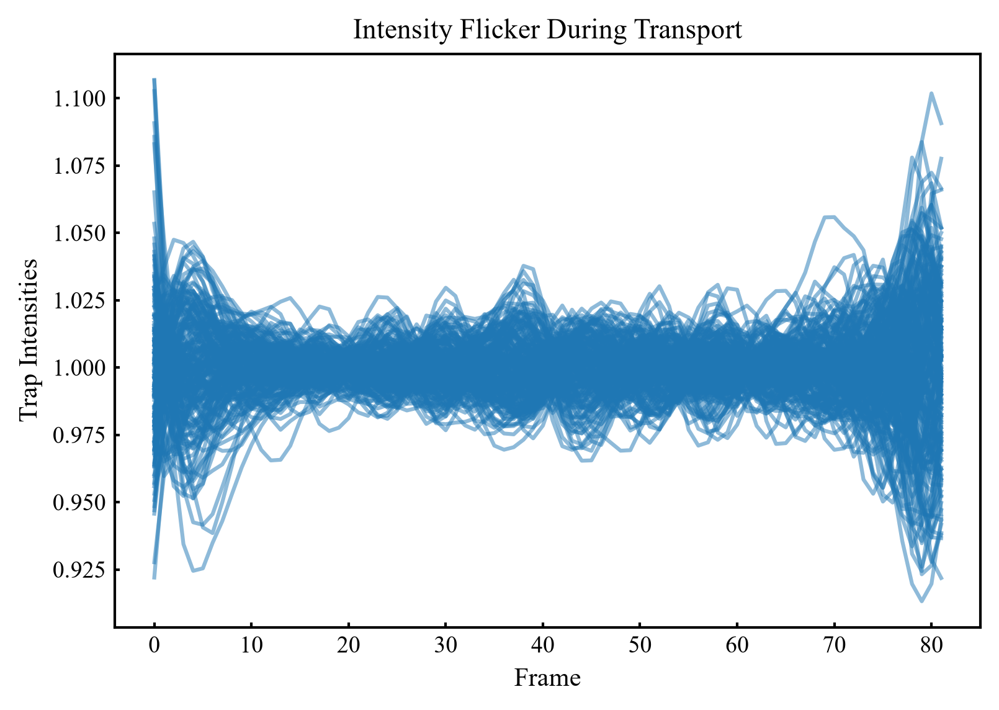

Standard deviation of trap intensities (LPI): 0.0124 (mean), 0.0257 (max), 0.0062 (min)


In [14]:
plt.figure(figsize=(6, 4))
for n in range(phi_foc_array_lpi_1.shape[1]):
    plt.plot(np.arange(I_foc_array_lpi_1.shape[0]-1), I_foc_array_lpi_1[1:, n]/np.mean(I_foc_array_lpi_1[-1, :]), alpha=0.5, color='C0')
                
plt.xlabel("Frame")
plt.ylabel("Trap Intensities")
plt.title(f"Intensity Flicker During Transport")
plt.show()

std = np.std(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]), axis=0)
print(f"Standard deviation of trap intensities (LPI): {std.mean():.4f} (mean), {std.max():.4f} (max), {std.min():.4f} (min)")

### Phase Flicker

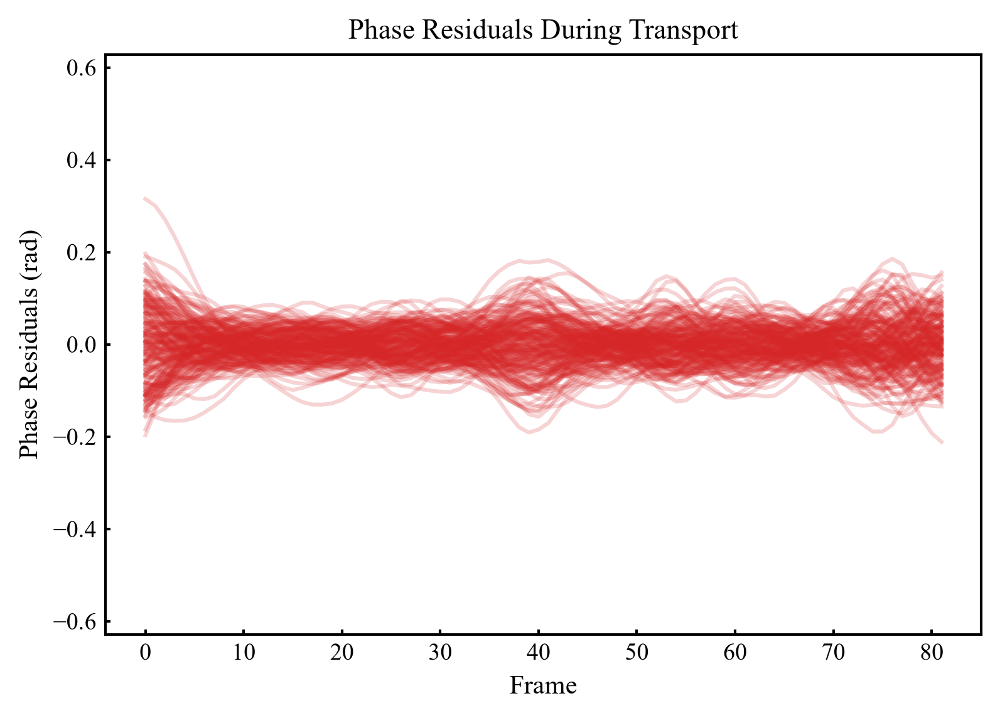

Standard deviation of phase residuals (LPI): 0.0441 rad


In [15]:
from scipy.optimize import curve_fit

plt.figure(figsize=(6, 4))
residuals_list = []

lin_fit = lambda x, m, b: m * x + b
for n in range(phi_foc_array_lpi_1.shape[1]):
    x = np.arange(phi_foc_array_lpi_1.shape[0]-1)
    y = np.unwrap(phi_foc_array_lpi_1[1:, n])
    popt, pcov = curve_fit(lin_fit, x, y)
    y_fit = lin_fit(x, *popt)
    residuals = y - y_fit
    #plt.plot(x, y, alpha=0.5, color='C0')
    #plt.plot(x, y_fit, alpha=0.8, color='C1')
    plt.plot(x, residuals, alpha=0.2, color='C3')
    residuals_list.append(residuals)

plt.ylim(-np.pi/5, np.pi/5)
plt.xlabel("Frame")
plt.ylabel("Phase Residuals (rad)")
plt.title(f"Phase Residuals During Transport")
plt.show()

residuals_array = np.array(residuals_list).flatten()
std_residuals = np.std(residuals_array)
print(f"Standard deviation of phase residuals (LPI): {std_residuals:.4f} rad")

## Situation 3: Two Iterations Weight Equalisation

In [16]:
w_array, phi_array, x_array, y_array, pm_slm_array = iter_rearrangement_sequence(terms1, terms2, occupancy_mask, d0=0.25,
                                profile="linear", 
                                refine_iters=2, refine_damping=0.35,
                                init_refine_iters=1, init_refine_damping=0.35
                                )

In [17]:
w_on_array = []
phi_on_array = []
x_on_array = []
y_on_array = []

for i in range(w_array.shape[1]):
    if w_array[-1, i] > 0:
        w_on_array.append(w_array[:, i])
        phi_on_array.append(phi_array[:, i])
        x_on_array.append(x_array[:, i])
        y_on_array.append(y_array[:, i])

w_on_array = np.array(w_on_array).T
phi_on_array = np.array(phi_on_array).T
x_on_array = np.array(x_on_array).T
y_on_array = np.array(y_on_array).T

I_foc_array_lpi_2 = np.zeros_like(w_on_array)
phi_foc_array_lpi_2 = np.zeros_like(phi_on_array)
for i in range(pm_slm_array.shape[0]):
    pm_slm = pm_slm_array[i]
    x_n = x_on_array[i]
    y_n = y_on_array[i]
    I_foc, phi_foc = PM.evaluate_traps(pm_slm, x_n, y_n)
    I_foc_array_lpi_2[i] = I_foc / I_foc.mean()
    phi_foc_array_lpi_2[i] = phi_foc

#### Intensity Drift

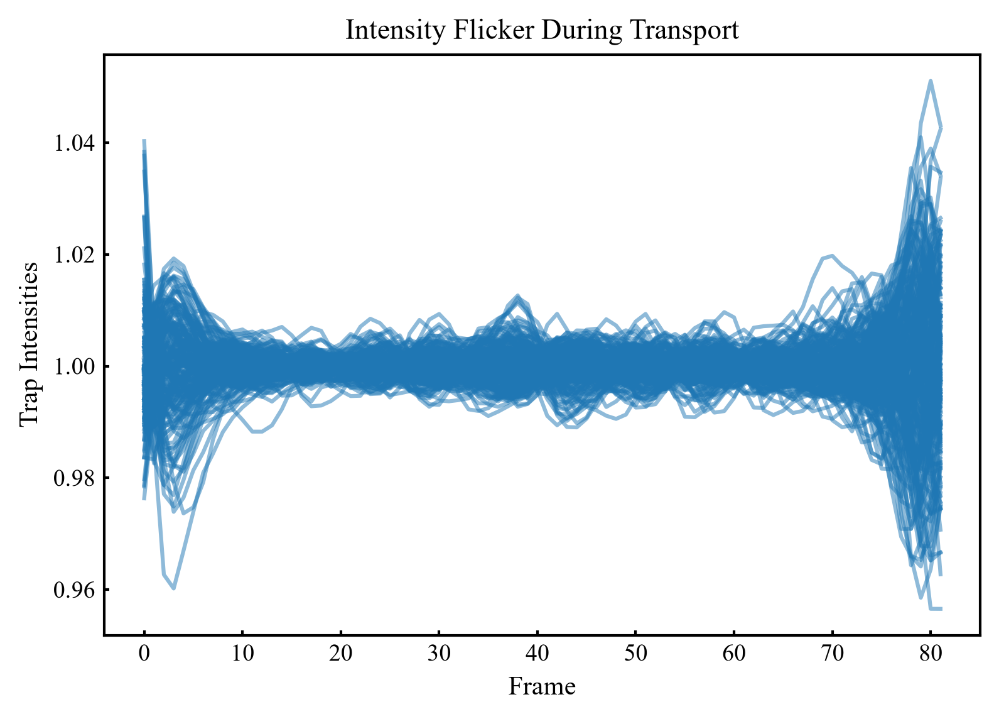

Standard deviation of trap intensities (LPI): 0.0048 (mean), 0.0113 (max), 0.0019 (min)


In [18]:
plt.figure(figsize=(6, 4))
for n in range(phi_foc_array_lpi_2.shape[1]):
    plt.plot(np.arange(I_foc_array_lpi_2.shape[0]-1), I_foc_array_lpi_2[1:, n]/np.mean(I_foc_array_lpi_2[-1, :]), alpha=0.5, color='C0')
                
plt.xlabel("Frame")
plt.ylabel("Trap Intensities")
plt.title(f"Intensity Flicker During Transport")
plt.show()

std = np.std(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]), axis=0)
print(f"Standard deviation of trap intensities (LPI): {std.mean():.4f} (mean), {std.max():.4f} (max), {std.min():.4f} (min)")

### Phase Flicker

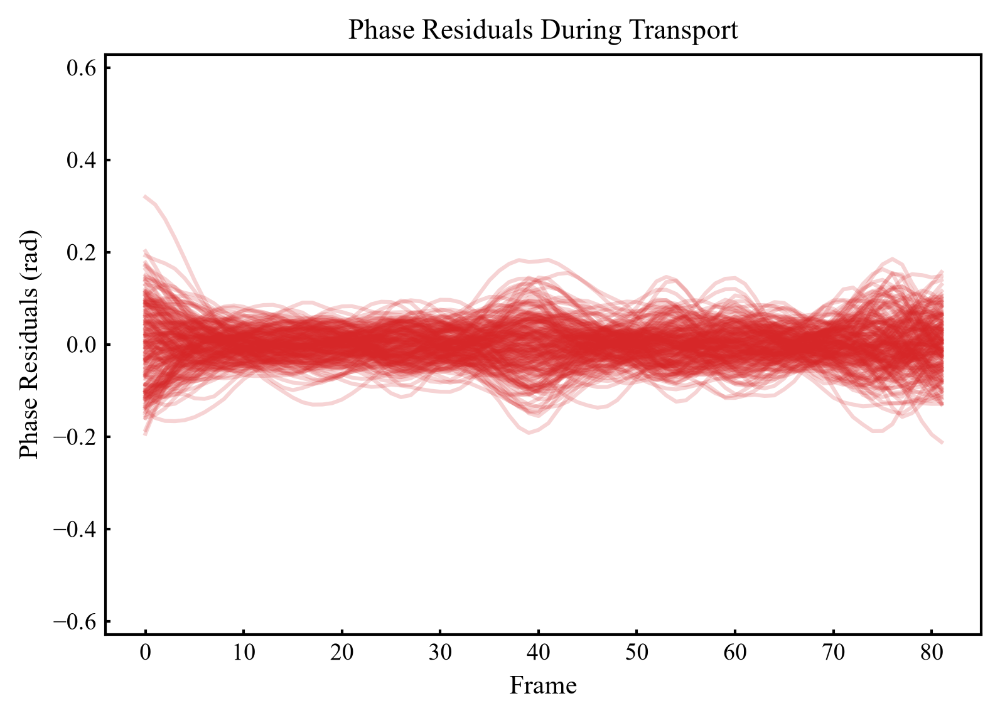

Standard deviation of phase residuals (LPI_2): 0.0441 rad


In [19]:
from scipy.optimize import curve_fit

plt.figure(figsize=(6, 4))
residuals_list = []

lin_fit = lambda x, m, b: m * x + b
for n in range(phi_foc_array_lpi_2.shape[1]):
    x = np.arange(phi_foc_array_lpi_2.shape[0]-1)
    y = np.unwrap(phi_foc_array_lpi_2[1:, n])
    popt, pcov = curve_fit(lin_fit, x, y)
    y_fit = lin_fit(x, *popt)
    residuals = y - y_fit
    #plt.plot(x, y, alpha=0.5, color='C0')
    #plt.plot(x, y_fit, alpha=0.8, color='C1')
    plt.plot(x, residuals, alpha=0.2, color='C3')
    residuals_list.append(residuals)

plt.ylim(-np.pi/5, np.pi/5)
plt.xlabel("Frame")
plt.ylabel("Phase Residuals (rad)")
plt.title(f"Phase Residuals During Transport")
plt.show()

residuals_array = np.array(residuals_list).flatten()
std_residuals = np.std(residuals_array)
print(f"Standard deviation of phase residuals (LPI_2): {std_residuals:.4f} rad")

---
## Situation 4: Flat Weights

In [20]:
def iter_rearrangement_sequence_flat(terms1, terms2, occ_mask, d0=0.5,
                                profile="linear"):

    if profile not in ("minimum_jerk", "linear"):
        raise ValueError(
            f"profile must be 'minimum_jerk' or 'linear', got {profile!r}"
        )
    w1, phi1, x1, y1 = terms1
    w2, phi2, x2, y2 = terms2
    occ_mask = cp.asarray(occ_mask)

    pos1 = cp.stack((x1, y1), axis=-1)
    pos2 = cp.stack((x2, y2), axis=-1)

    occ_indices = cp.where(occ_mask)[0]
    init = pos1[occ_indices]
    final = pos2

    init_idx, final_idx = get_jv_pairing_lap(init, final)
    moving_idx = occ_indices[init_idx]

    off_mask = cp.ones(len(pos1), dtype=bool)
    off_mask[moving_idx] = False

    pos_init = pos1[moving_idx]
    pos_final = pos2[final_idx]
    vec = pos_final - pos_init

    max_dist = cp.linalg.norm(vec, axis=1).max()
    steps_scale = 1.0 if profile == "linear" else 1.875
    n_steps = int(cp.ceil(steps_scale * max_dist / d0))

    curr_w = cp.asarray(w1, dtype=cp.float32)
    curr_phi = cp.asarray(phi1, dtype=cp.float32)
    curr_x = cp.asarray(x1, dtype=cp.float32)
    curr_y = cp.asarray(y1, dtype=cp.float32)

    tau = cp.linspace(0, 1, n_steps + 1, dtype=cp.float32)
    if profile == "linear":
        s_profile = tau
    else:
        s_profile = 10 * tau**3 - 15 * tau**4 + 6 * tau**5
    ds_profile_cpu = cp.diff(s_profile).get()

    dw = cp.zeros_like(curr_w)
    dphi = cp.zeros_like(curr_phi)
    total_dx = cp.zeros_like(curr_x)
    total_dy = cp.zeros_like(curr_y)

    w1_gpu, w2_gpu = cp.asarray(w1), cp.asarray(w2)
    phi1_gpu, phi2_gpu = cp.asarray(phi1), cp.asarray(phi2)

    dw[moving_idx] = (w2_gpu[final_idx] - w1_gpu[moving_idx]) / n_steps
    total_dx[moving_idx] = vec[:, 0].astype(cp.float32)
    total_dy[moving_idx] = vec[:, 1].astype(cp.float32)

    phase_diff = (phi2_gpu[final_idx] - phi1_gpu[moving_idx] + cp.pi) % (2 * cp.pi) - cp.pi
    dphi[moving_idx] = phase_diff / n_steps

    dw[off_mask] = 0.0
    curr_w[off_mask] = 0.0

    dw[moving_idx] = 0.0
    curr_w[moving_idx] = 1.0

    w_list, phi_list, x_list, y_list = [], [], [], []
    pm_slm_sequence = []

    for n in range(n_steps):
        ds = float(ds_profile_cpu[n])
        update_state_kernel(dw, dphi, total_dx, total_dy, ds, curr_w, curr_phi, curr_x, curr_y)
        terms_gpu = (curr_w, curr_phi, curr_x, curr_y)

        pm_slm = PM.generate_phasemask(terms_gpu)
        
        w_list.append(curr_w.get())
        phi_list.append(curr_phi.get())
        x_list.append(curr_x.get())
        y_list.append(curr_y.get())
        pm_slm_sequence.append(pm_slm.get())

    w_array = np.array(w_list)
    phi_array = np.array(phi_list)
    x_array = np.array(x_list)
    y_array = np.array(y_list)
    pm_slm_array = np.array(pm_slm_sequence)
        
    return w_array, phi_array, x_array, y_array, pm_slm_array

In [21]:
w_array, phi_array, x_array, y_array, pm_slm_array = iter_rearrangement_sequence_flat(terms1, terms2, occupancy_mask, d0=0.25,
                                profile="linear")

In [22]:

w_on_array = []
phi_on_array = []
x_on_array = []
y_on_array = []

for i in range(w_array.shape[1]):
    if w_array[-1, i] > 0:
        w_on_array.append(w_array[:, i])
        phi_on_array.append(phi_array[:, i])
        x_on_array.append(x_array[:, i])
        y_on_array.append(y_array[:, i])

w_on_array = np.array(w_on_array).T
phi_on_array = np.array(phi_on_array).T
x_on_array = np.array(x_on_array).T
y_on_array = np.array(y_on_array).T

I_foc_array_lpi_3 = np.zeros_like(w_on_array)
phi_foc_array_lpi_3 = np.zeros_like(phi_on_array)

for i in range(pm_slm_array.shape[0]):
    pm_slm = pm_slm_array[i]
    x_n = x_on_array[i]
    y_n = y_on_array[i]
    I_foc, phi_foc = PM.evaluate_traps(pm_slm, x_n, y_n)
    I_foc_array_lpi_3[i] = I_foc / I_foc.mean()
    phi_foc_array_lpi_3[i] = phi_foc

#### Intensity Drift

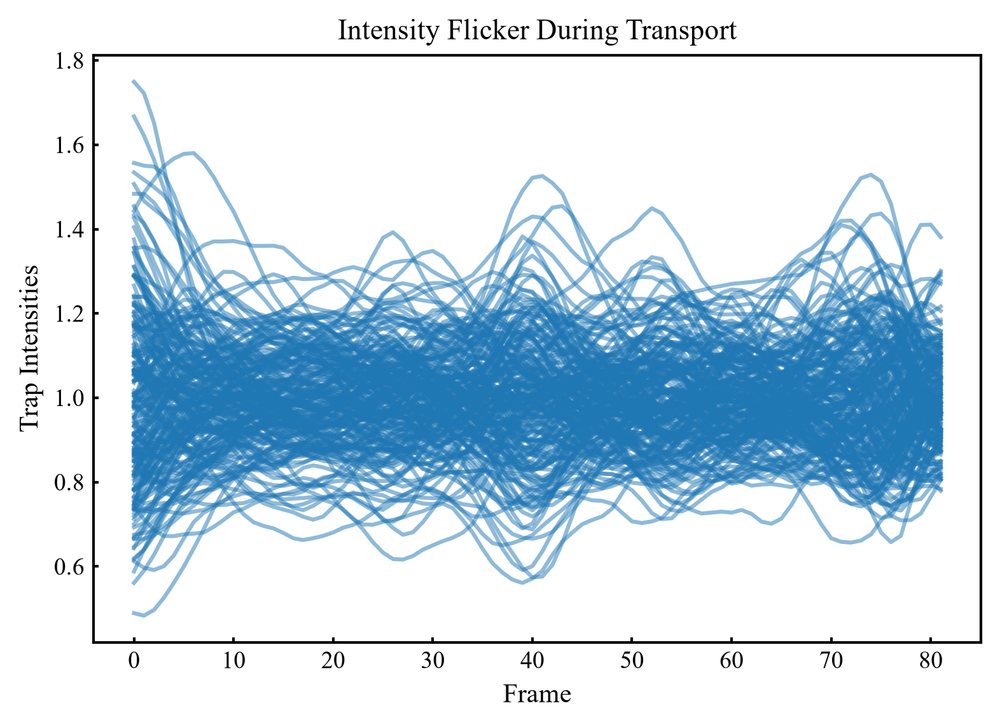

Standard deviation of trap intensities (LPI): 0.0988 (mean), 0.2237 (max), 0.0459 (min)


In [23]:
plt.figure(figsize=(6, 4))
for n in range(phi_foc_array_lpi_3.shape[1]):
    plt.plot(np.arange(I_foc_array_lpi_3.shape[0]-1), I_foc_array_lpi_3[1:, n]/np.mean(I_foc_array_lpi_3[-1, :]), alpha=0.5, color='C0')
                
plt.xlabel("Frame")
plt.ylabel("Trap Intensities")
plt.title(f"Intensity Flicker During Transport")
plt.show()

std = np.std(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]), axis=0)
print(f"Standard deviation of trap intensities (LPI): {std.mean():.4f} (mean), {std.max():.4f} (max), {std.min():.4f} (min)")

### Phase Flicker

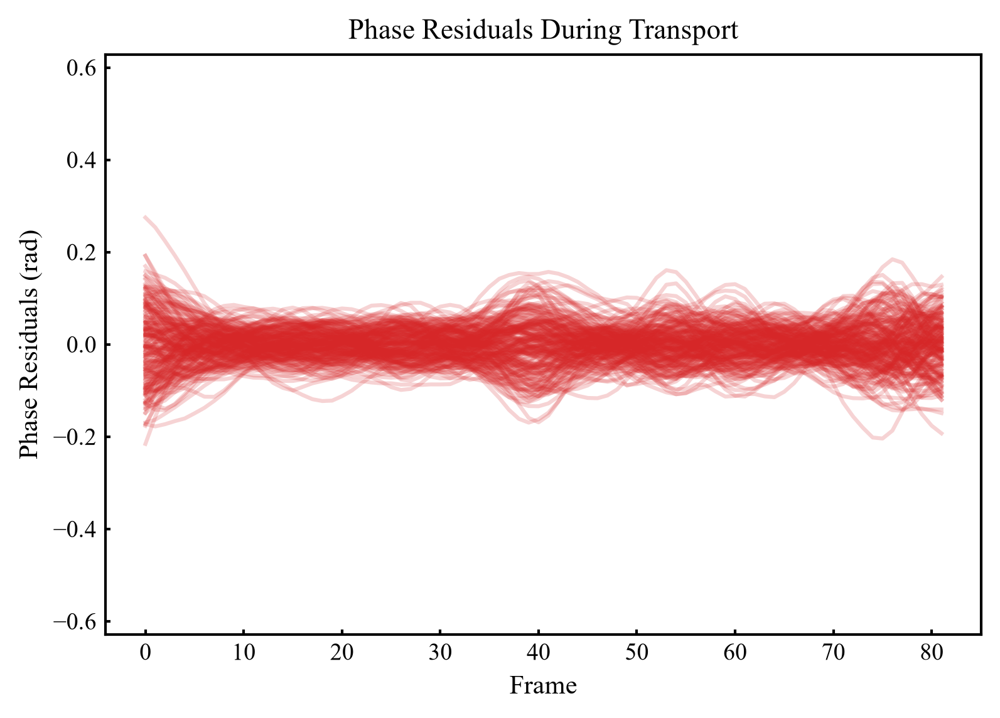

Standard deviation of phase residuals (LPI): 0.0426 rad


In [24]:
from scipy.optimize import curve_fit

plt.figure(figsize=(6, 4))
residuals_list = []

lin_fit = lambda x, m, b: m * x + b
for n in range(phi_foc_array_lpi_3.shape[1]):
    x = np.arange(phi_foc_array_lpi_3.shape[0]-1)
    y = np.unwrap(phi_foc_array_lpi_3[1:, n])
    popt, pcov = curve_fit(lin_fit, x, y)
    y_fit = lin_fit(x, *popt)
    residuals = y - y_fit
    #plt.plot(x, y, alpha=0.5, color='C0')
    #plt.plot(x, y_fit, alpha=0.8, color='C1')
    plt.plot(x, residuals, alpha=0.2, color='C3')
    residuals_list.append(residuals)

plt.ylim(-np.pi/5, np.pi/5)
plt.xlabel("Frame")
plt.ylabel("Phase Residuals (rad)")
plt.title(f"Phase Residuals During Transport")
plt.show()

residuals_array = np.array(residuals_list).flatten()
std_residuals = np.std(residuals_array)
print(f"Standard deviation of phase residuals (LPI): {std_residuals:.4f} rad")

---
## Phase Shifts per Frame

#### Linear Weight Interpolation

In [25]:
dphi_max_list = []
dphi_mean_list = []
dphi_total_list = []
for n in range(phi_foc_array_lpi_0.shape[1]):
    phi_array_n = np.unwrap(phi_foc_array_lpi_0[:, n])
    max_phase_diff = np.max(np.abs(np.diff(phi_array_n)))
    mean_phase_diff = np.mean(np.abs(np.diff(phi_array_n)))
    total_phase_change = phi_array_n[-1] - phi_array_n[0]
    dphi_max_list.append(max_phase_diff)
    dphi_mean_list.append(mean_phase_diff)
    dphi_total_list.append(total_phase_change)

dphi_max = np.max(dphi_max_list)
dphi_mean = np.mean(dphi_mean_list)

print("Linear Weight Interpolation:")
print(f"    Maximum phase change per frame (LPI_0): {dphi_max/np.pi:.4f} pi rad")
print(f"    Mean phase change per frame (LPI_0): {dphi_mean/np.pi:.4f} pi rad")

Linear Weight Interpolation:
    Maximum phase change per frame (LPI_0): 0.0235 pi rad
    Mean phase change per frame (LPI_0): 0.0065 pi rad


#### Flat Weights

In [26]:
dphi_max_list = []
dphi_mean_list = []
dphi_total_list = []
for n in range(phi_foc_array_lpi_3.shape[1]):
    phi_array_n = np.unwrap(phi_foc_array_lpi_3[:, n])
    max_phase_diff = np.max(np.abs(np.diff(phi_array_n)))
    mean_phase_diff = np.mean(np.abs(np.diff(phi_array_n)))
    total_phase_change = phi_array_n[-1] - phi_array_n[0]
    dphi_max_list.append(max_phase_diff)
    dphi_mean_list.append(mean_phase_diff)
    dphi_total_list.append(total_phase_change)

dphi_max = np.max(dphi_max_list)
dphi_mean = np.mean(dphi_mean_list)

print("Flat Weights:")
print(f"    Maximum phase change per frame (LPI_3): {dphi_max/np.pi:.4f} pi rad")
print(f"    Mean phase change per frame (LPI_3): {dphi_mean/np.pi:.4f} pi rad")

Flat Weights:
    Maximum phase change per frame (LPI_3): 0.0245 pi rad
    Mean phase change per frame (LPI_3): 0.0065 pi rad


#### 1 Iteration - Weight Equalisation

In [27]:
dphi_max_list = []
dphi_mean_list = []
dphi_total_list = []
for n in range(phi_foc_array_lpi_1.shape[1]):
    phi_array_n = np.unwrap(phi_foc_array_lpi_1[:, n])
    max_phase_diff = np.max(np.abs(np.diff(phi_array_n)))
    mean_phase_diff = np.mean(np.abs(np.diff(phi_array_n)))
    total_phase_change = phi_array_n[-1] - phi_array_n[0]
    dphi_max_list.append(max_phase_diff)
    dphi_mean_list.append(mean_phase_diff)
    dphi_total_list.append(total_phase_change)

dphi_max = np.max(dphi_max_list)
dphi_mean = np.mean(dphi_mean_list)

print("Interpolation + 1 Iteration Weight Update:")
print(f"    Maximum phase change per frame (LPI_1): {dphi_max/np.pi:.4f} pi rad")
print(f"    Mean phase change per frame (LPI_1): {dphi_mean/np.pi:.4f} pi rad")

Interpolation + 1 Iteration Weight Update:
    Maximum phase change per frame (LPI_1): 0.0233 pi rad
    Mean phase change per frame (LPI_1): 0.0066 pi rad


#### 2 Iterations - Weight Equalisation

In [28]:
dphi_max_list = []
dphi_mean_list = []
dphi_total_list = []
for n in range(phi_foc_array_lpi_2.shape[1]):
    phi_array_n = np.unwrap(phi_foc_array_lpi_2[:, n])
    max_phase_diff = np.max(np.abs(np.diff(phi_array_n)))
    mean_phase_diff = np.mean(np.abs(np.diff(phi_array_n)))
    total_phase_change = phi_array_n[-1] - phi_array_n[0]
    dphi_max_list.append(max_phase_diff)
    dphi_mean_list.append(mean_phase_diff)
    dphi_total_list.append(total_phase_change)

dphi_max = np.max(dphi_max_list)
dphi_mean = np.mean(dphi_mean_list)

print("Interpolation + 2 Iteration Weight Update:")
print(f"    Maximum phase change per frame (LPI_2): {dphi_max/np.pi:.4f} pi rad")
print(f"    Mean phase change per frame (LPI_2): {dphi_mean/np.pi:.4f} pi rad")

Interpolation + 2 Iteration Weight Update:
    Maximum phase change per frame (LPI_2): 0.0236 pi rad
    Mean phase change per frame (LPI_2): 0.0066 pi rad


In [29]:
np.cos(0.0067*np.pi/2)**2

np.float64(0.9998892424539284)

---
## Intensity Flicker

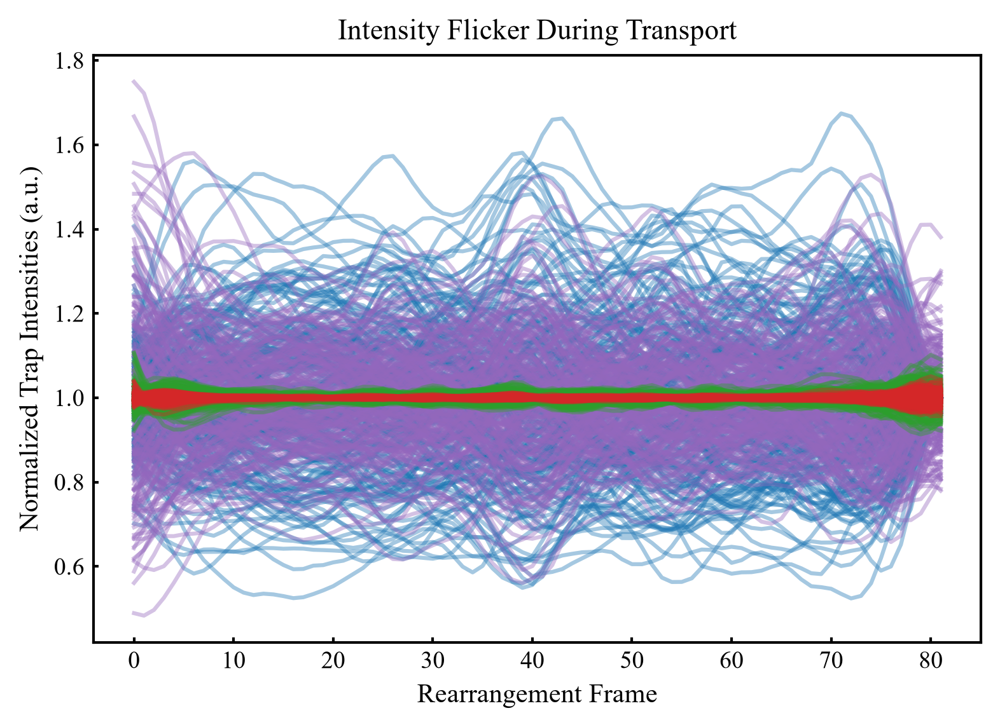

Std of trap intensities (LPI_0): 0.1685 (mean), 1.6743 (max), 0.5244 (min)
Std of trap intensities (LPI_1): 0.0129 (mean), 1.1068 (max), 0.9132 (min)
Std of trap intensities (LPI_2): 0.0051 (mean), 1.0510 (max), 0.9566 (min)
Std of trap intensities (LPI_3): 0.1277 (mean), 1.7492 (max), 0.4835 (min)


In [30]:
plt.figure(figsize=(6, 4))
for n in range(phi_foc_array_lpi_0.shape[1]):
    plt.plot(np.arange(I_foc_array_lpi_0.shape[0]-1), I_foc_array_lpi_0[1:, n]/np.mean(I_foc_array_lpi_0[-1, :]), alpha=0.4, color='C0')

for n in range(phi_foc_array_lpi_3.shape[1]):
    plt.plot(np.arange(I_foc_array_lpi_3.shape[0]-1), I_foc_array_lpi_3[1:, n]/np.mean(I_foc_array_lpi_3[-1, :]), alpha=0.4, color='C4')

for n in range(phi_foc_array_lpi_1.shape[1]):
    plt.plot(np.arange(I_foc_array_lpi_1.shape[0]-1), I_foc_array_lpi_1[1:, n]/np.mean(I_foc_array_lpi_1[-1, :]), alpha=0.4, color='C2')

for n in range(phi_foc_array_lpi_2.shape[1]):
    plt.plot(np.arange(I_foc_array_lpi_2.shape[0]-1), I_foc_array_lpi_2[1:, n]/np.mean(I_foc_array_lpi_2[-1, :]), alpha=0.4, color='C3')
            
plt.xlabel("Rearrangement Frame")
plt.ylabel("Normalized Trap Intensities (a.u.)")
plt.title(f"Intensity Flicker During Transport")
plt.show()

std_0 = np.std(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]))
max_0 = np.max(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]))
min_0 = np.min(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]))

std_1 = np.std(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]))
max_1 = np.max(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]))
min_1 = np.min(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]))

std_2 = np.std(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]))
max_2 = np.max(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]))
min_2 = np.min(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]))

std_3 = np.std(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]))
max_3 = np.max(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]))
min_3 = np.min(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]))

print(f"Std of trap intensities (LPI_0): {std_0:.4f} (mean), {max_0:.4f} (max), {min_0:.4f} (min)")
print(f"Std of trap intensities (LPI_1): {std_1:.4f} (mean), {max_1:.4f} (max), {min_1:.4f} (min)")
print(f"Std of trap intensities (LPI_2): {std_2:.4f} (mean), {max_2:.4f} (max), {min_2:.4f} (min)")
print(f"Std of trap intensities (LPI_3): {std_3:.4f} (mean), {max_3:.4f} (max), {min_3:.4f} (min)")

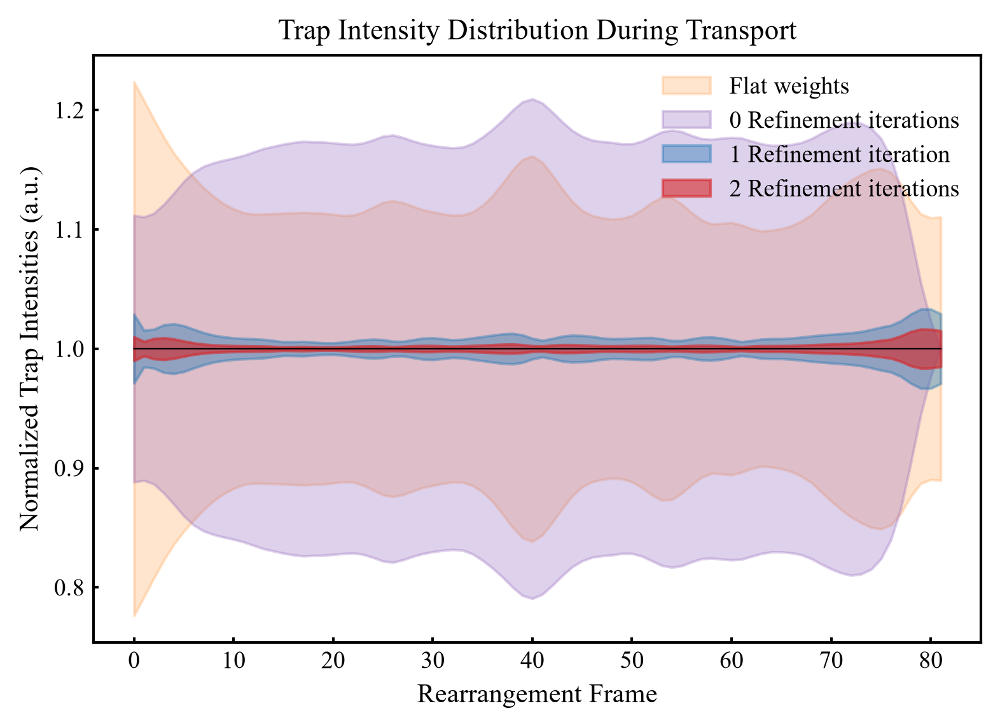

Std of trap intensities (LPI_0): 0.1685, Max 1.6743, Min 0.5244
Std of trap intensities (LPI_1): 0.0129, Max 1.1068, Min 0.9132
Std of trap intensities (LPI_2): 0.0051, Max 1.0510, Min 0.9566
Std of trap intensities (LPI_3): 0.1277, Max 1.7492, Min 0.4835


In [31]:
plt.figure(figsize=(6, 4))

plt.fill_between(np.arange(I_foc_array_lpi_3.shape[0]-1),
                 1-np.std(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]), axis=1),
                 1+np.std(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]), axis=1),
                 color='C1', alpha=0.2, label='Flat weights')

plt.fill_between(np.arange(I_foc_array_lpi_0.shape[0]-1),
                 1-np.std(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]), axis=1),
                 1+np.std(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]), axis=1),
                 color='C4', alpha=0.3, label='0 Refinement iterations')

plt.fill_between(np.arange(I_foc_array_lpi_1.shape[0]-1),
                 1-np.std(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]), axis=1),
                 1+np.std(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]), axis=1),
                 color='C0', alpha=0.4, label='1 Refinement iteration')

plt.fill_between(np.arange(I_foc_array_lpi_2.shape[0]-1),
                 1-np.std(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]), axis=1),
                 1+np.std(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]), axis=1),
                 color='C3', alpha=0.6, label='2 Refinement iterations')
plt.plot(np.arange(I_foc_array_lpi_2.shape[0]-1), np.mean(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]), axis=1), color='black', linewidth=0.5)
            
plt.xlabel("Rearrangement Frame")
plt.ylabel("Normalized Trap Intensities (a.u.)")
plt.title(f"Trap Intensity Distribution During Transport")
plt.legend()
plt.show()

std_0 = np.std(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]))
max_0 = np.max(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]))
min_0 = np.min(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]))

std_1 = np.std(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]))
max_1 = np.max(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]))
min_1 = np.min(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]))

std_2 = np.std(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]))
max_2 = np.max(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]))
min_2 = np.min(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]))

std_3 = np.std(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]))
max_3 = np.max(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]))
min_3 = np.min(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]))

print(f"Std of trap intensities (LPI_0): {std_0:.4f}, Max {max_0:.4f}, Min {min_0:.4f}")
print(f"Std of trap intensities (LPI_1): {std_1:.4f}, Max {max_1:.4f}, Min {min_1:.4f}")
print(f"Std of trap intensities (LPI_2): {std_2:.4f}, Max {max_2:.4f}, Min {min_2:.4f}")
print(f"Std of trap intensities (LPI_3): {std_3:.4f}, Max {max_3:.4f}, Min {min_3:.4f}")

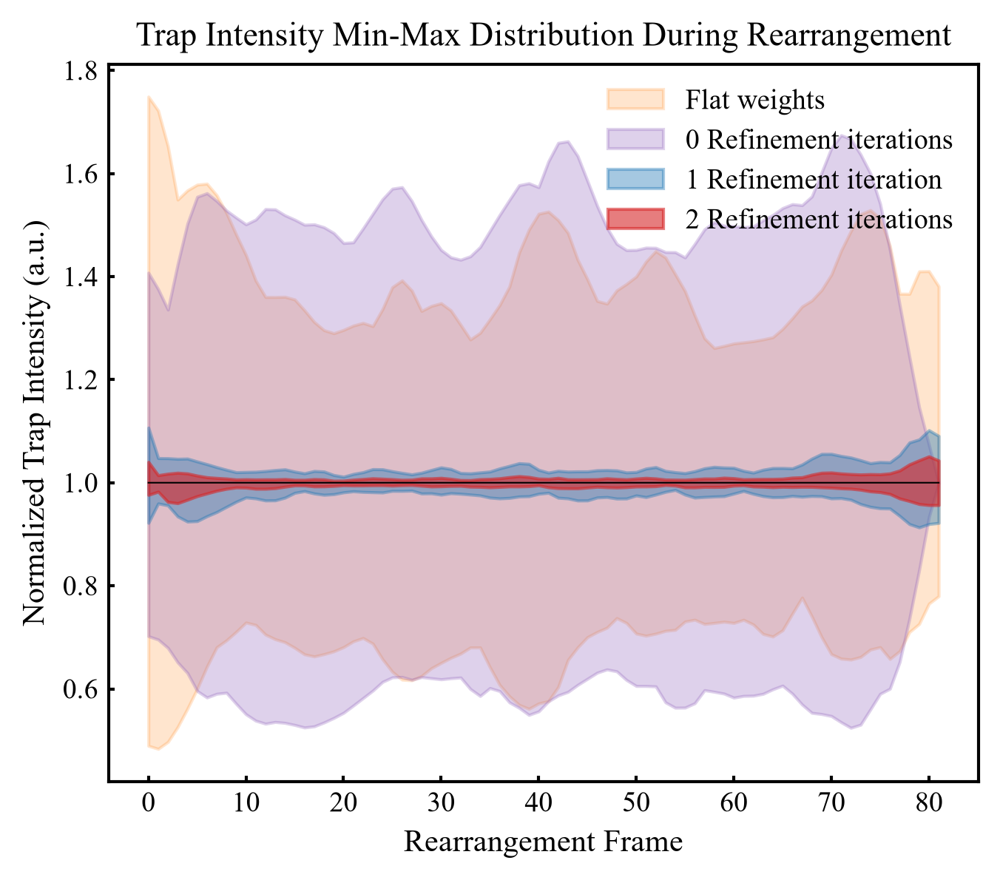

Std of trap intensities (LPI_0): 0.1685, Max 1.6743, Min 0.5244
Std of trap intensities (LPI_1): 0.0129, Max 1.1068, Min 0.9132
Std of trap intensities (LPI_2): 0.0051, Max 1.0510, Min 0.9566
Std of trap intensities (LPI_3): 0.1277, Max 1.7492, Min 0.4835


In [32]:
plt.figure()

plt.fill_between(np.arange(I_foc_array_lpi_3.shape[0]-1),
                 np.min(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]), axis=1),
                 np.max(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]), axis=1),
                 color='C1', alpha=0.2, label='Flat weights')

plt.fill_between(np.arange(I_foc_array_lpi_0.shape[0]-1),
                 np.min(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]), axis=1),
                 np.max(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]), axis=1),
                 color='C4', alpha=0.3, label='0 Refinement iterations')

plt.fill_between(np.arange(I_foc_array_lpi_1.shape[0]-1),
                 np.min(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]), axis=1),
                 np.max(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]), axis=1),
                 color='C0', alpha=0.4, label='1 Refinement iteration')

plt.fill_between(np.arange(I_foc_array_lpi_2.shape[0]-1),
                 np.min(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]), axis=1),
                 np.max(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]), axis=1),
                 color='C3', alpha=0.6, label='2 Refinement iterations')
plt.plot(np.arange(I_foc_array_lpi_2.shape[0]-1), np.mean(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]), axis=1), color='black', linewidth=0.5)
            
plt.xlabel("Rearrangement Frame")
plt.ylabel("Normalized Trap Intensity (a.u.)")
plt.title(f"Trap Intensity Min-Max Distribution During Rearrangement")
plt.legend()
plt.show()

std_0 = np.std(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]))
max_0 = np.max(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]))
min_0 = np.min(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]))

std_1 = np.std(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]))
max_1 = np.max(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]))
min_1 = np.min(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]))

std_2 = np.std(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]))
max_2 = np.max(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]))
min_2 = np.min(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]))

std_3 = np.std(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]))
max_3 = np.max(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]))
min_3 = np.min(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]))

print(f"Std of trap intensities (LPI_0): {std_0:.4f}, Max {max_0:.4f}, Min {min_0:.4f}")
print(f"Std of trap intensities (LPI_1): {std_1:.4f}, Max {max_1:.4f}, Min {min_1:.4f}")
print(f"Std of trap intensities (LPI_2): {std_2:.4f}, Max {max_2:.4f}, Min {min_2:.4f}")
print(f"Std of trap intensities (LPI_3): {std_3:.4f}, Max {max_3:.4f}, Min {min_3:.4f}")

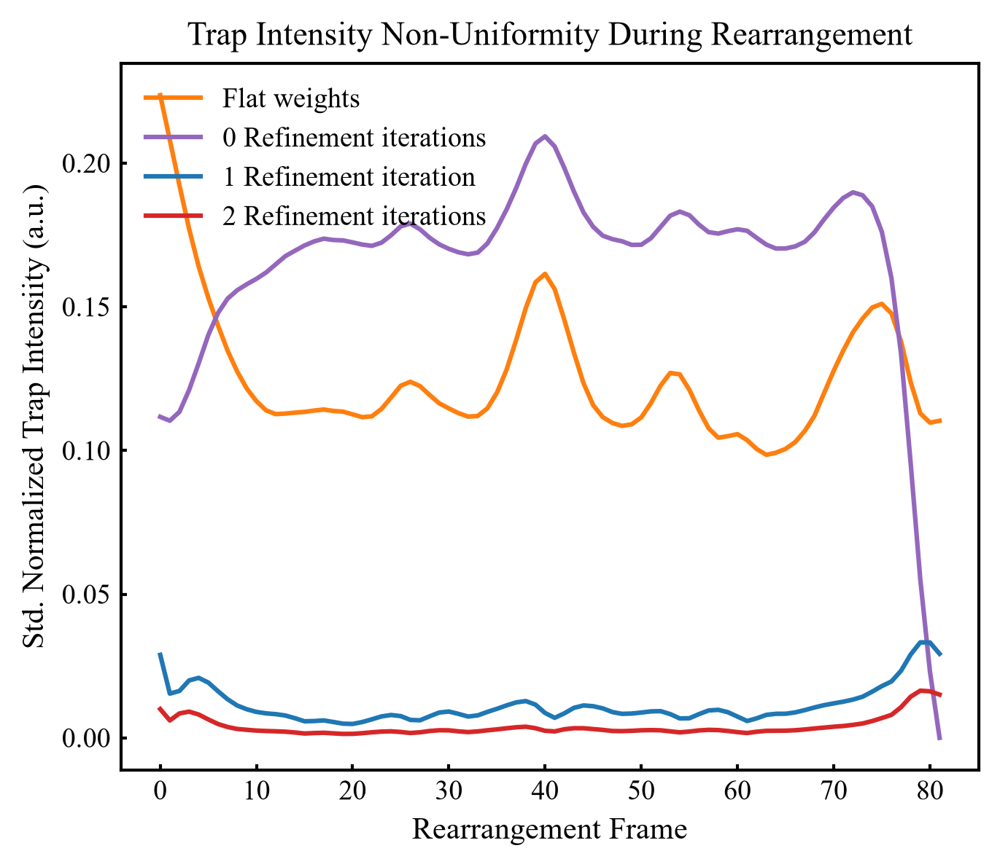

In [33]:
plt.figure()

plt.plot(np.arange(I_foc_array_lpi_3.shape[0]-1),
                 np.std(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]), axis=1),
                 color='C1', alpha=1, label='Flat weights')

plt.plot(np.arange(I_foc_array_lpi_0.shape[0]-1),
                 np.std(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]), axis=1),
                 color='C4', alpha=1, label='0 Refinement iterations')

plt.plot(np.arange(I_foc_array_lpi_1.shape[0]-1),
                 np.std(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]), axis=1),
                 color='C0', alpha=1, label='1 Refinement iteration')

plt.plot(np.arange(I_foc_array_lpi_2.shape[0]-1),
                 np.std(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]), axis=1),
                 color='C3', alpha=1, label='2 Refinement iterations')

            
plt.xlabel("Rearrangement Frame")
plt.ylabel("Std. Normalized Trap Intensiity (a.u.)")
plt.title(f"Trap Intensity Non-Uniformity During Rearrangement")
plt.legend()
plt.show()


C:\Users\tweez\AppData\Local\Temp\ipykernel_27688\865575436.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


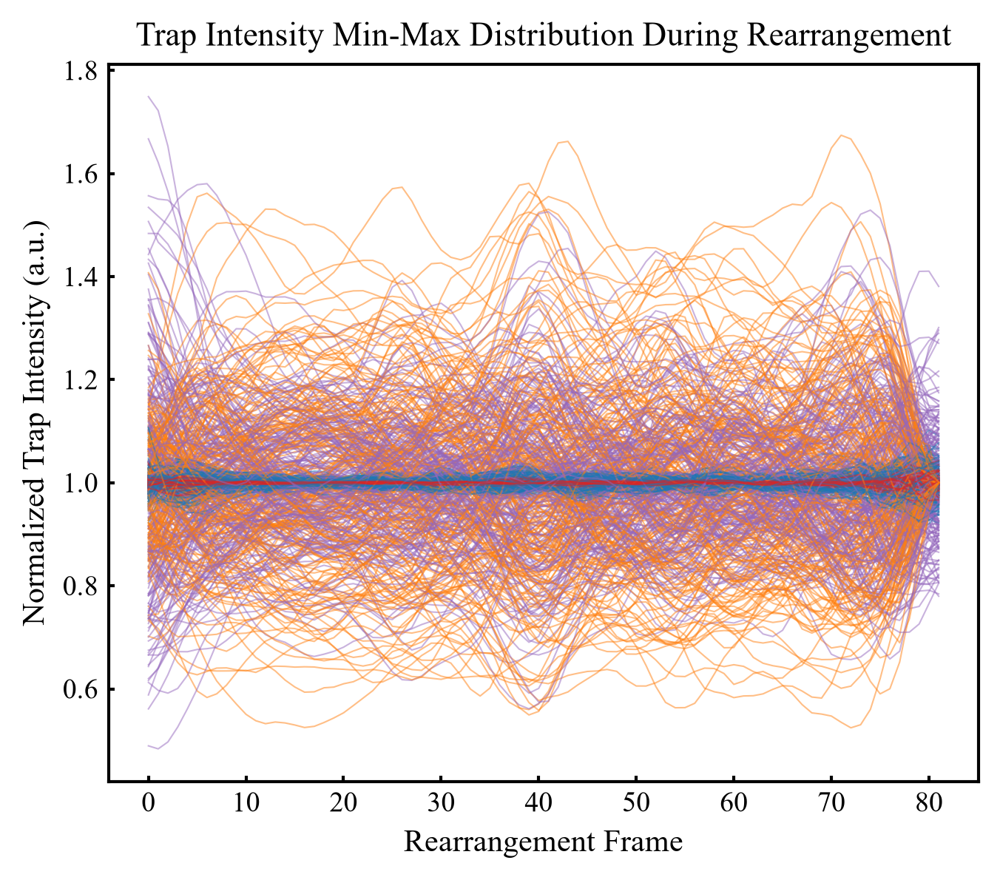

In [34]:
plt.plot(np.arange(I_foc_array_lpi_2.shape[0]-1), np.mean(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]), axis=1), color='black', linewidth=0.5)

for n in range(phi_foc_array_lpi_0.shape[1]):
    plt.plot(np.arange(I_foc_array_lpi_0.shape[0]-1), I_foc_array_lpi_0[1:, n]/np.mean(I_foc_array_lpi_0[-1, :]), alpha=0.5, color='C1', linewidth=0.5)
    plt.plot(np.arange(I_foc_array_lpi_1.shape[0]-1), I_foc_array_lpi_1[1:, n]/np.mean(I_foc_array_lpi_1[-1, :]), alpha=0.5, color='C0', linewidth=0.5)
    plt.plot(np.arange(I_foc_array_lpi_2.shape[0]-1), I_foc_array_lpi_2[1:, n]/np.mean(I_foc_array_lpi_2[-1, :]), alpha=0.5, color='C3', linewidth=0.5)
    plt.plot(np.arange(I_foc_array_lpi_3.shape[0]-1), I_foc_array_lpi_3[1:, n]/np.mean(I_foc_array_lpi_3[-1, :]), alpha=0.5, color='C4', linewidth=0.5)

plt.xlabel("Rearrangement Frame")
plt.ylabel("Normalized Trap Intensity (a.u.)")
plt.title(f"Trap Intensity Min-Max Distribution During Rearrangement")
plt.legend()

## Trap Intensity Flicker vs Num Iterations

In [35]:
num_it_list = np.arange(6)

In [36]:
std_list = []
min_list = []
max_list = []
std_residuals_list = []

for refine_iters in num_it_list:
    w_array, phi_array, x_array, y_array, pm_slm_array = iter_rearrangement_sequence(terms1, terms2, occupancy_mask, d0=0.25,
                                    profile="linear", 
                                    refine_iters=refine_iters, refine_damping=0.25)

    w0, phi0, x0, y0 = terms1
    w0, phi0, x0, y0 = w0.get(), phi0.get(), x0.get(), y0.get()
    pm_slm_0 = pm_array1.get()

    w_on_array = []
    phi_on_array = []
    x_on_array = []
    y_on_array = []

    for i in range(w_array.shape[1]):
        if w_array[-1, i] > 0:
            w_on_array.append(w_array[:, i])
            phi_on_array.append(phi_array[:, i])
            x_on_array.append(x_array[:, i])
            y_on_array.append(y_array[:, i])

    w_on_array = np.array(w_on_array).T
    phi_on_array = np.array(phi_on_array).T
    x_on_array = np.array(x_on_array).T
    y_on_array = np.array(y_on_array).T

    I_foc_array_lpi = np.zeros_like(w_on_array)
    phi_foc_array_lpi = np.zeros_like(phi_on_array)
    for i in range(pm_slm_array.shape[0]):
        pm_slm = pm_slm_array[i]
        x_n = x_on_array[i]
        y_n = y_on_array[i]
        I_foc, phi_foc = PM.evaluate_traps(pm_slm, x_n, y_n)
        I_foc_array_lpi[i] = I_foc / I_foc.mean()
        phi_foc_array_lpi[i] = phi_foc

    phi_array = phi_foc_array_lpi
    residuals_list = []
    lin_fit = lambda x, m, b: m * x + b
    for n in range(phi_array.shape[1]):
        x = np.arange(phi_array.shape[0]-1)
        y = np.unwrap(phi_array[1:, n])
        popt, pcov = curve_fit(lin_fit, x, y)
        y_fit = lin_fit(x, *popt)
        residuals = y - y_fit
        residuals_list.append(residuals)

    residuals_array = np.array(residuals_list).flatten()
    std_residuals = np.std(residuals_array)
    std_residuals_list.append(std_residuals)

    std = np.std(I_foc_array_lpi[1:, :]/np.mean(I_foc_array_lpi[-1, :]))
    min_val = np.min(I_foc_array_lpi[1:, :]/np.mean(I_foc_array_lpi[-1, :]))
    max_val = np.max(I_foc_array_lpi[1:, :]/np.mean(I_foc_array_lpi[-1, :]))

    std_list.append(std)
    min_list.append(min_val)
    max_list.append(max_val)

Text(0.5, 1.0, 'Effect of Equalization Iterations on Trap Non-Uniformity')

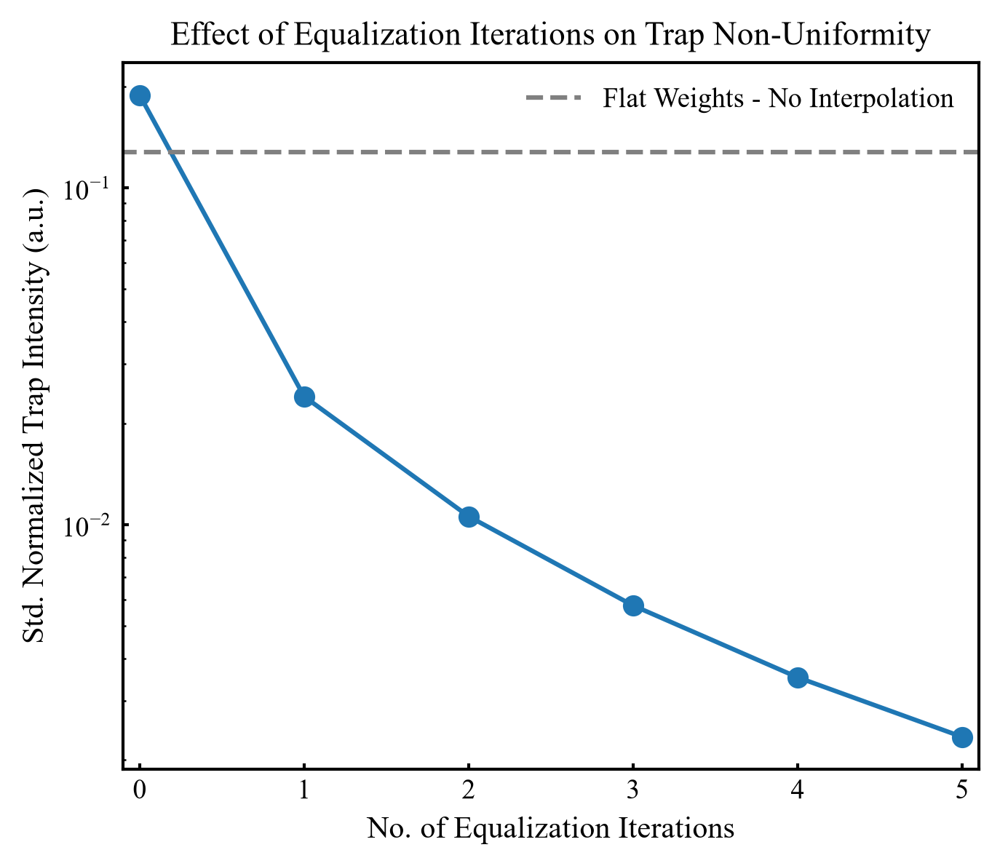

In [37]:
# Plot num_it vs std

plt.plot(num_it_list, std_list, marker='o')
plt.hlines(y=[std_3], xmin=num_it_list[0]-1, xmax=num_it_list[-1]+1, color='gray', linestyle='--', label='Flat Weights - No Interpolation')
plt.xlim(-0.1, 5.1)
plt.yscale('log')
plt.legend()
plt.xlabel('No. of Equalization Iterations')
plt.ylabel('Std. Normalized Trap Intensity (a.u.)')
plt.title('Effect of Equalization Iterations on Trap Non-Uniformity')

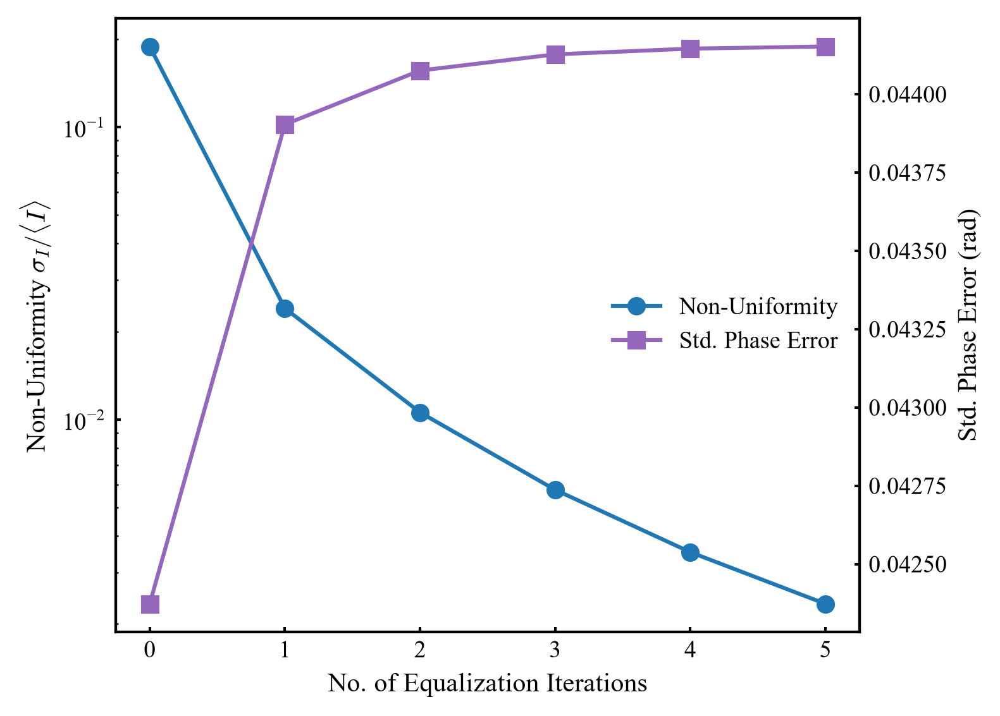

In [38]:
# Plot std_residuals_list and std_list on the same plot with a secondary y-axis

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
plot1 = ax1.plot(num_it_list, std_list, marker='o', color='C0', label='Non-Uniformity')
plot2 = ax2.plot(num_it_list, std_residuals_list, marker='s', color='C4', label='Std. Phase Error')

ax1.set_xlabel('No. of Equalization Iterations')
ax1.set_ylabel(r'Non-Uniformity $\sigma_I/\langle I \rangle$')
ax2.set_ylabel('Std. Phase Error (rad)')
ax1.legend(handles=[plot1[0], plot2[0]], loc='right')
ax1.set_yscale('log')

In [39]:
std_list

[np.float32(0.18856572),
 np.float32(0.024010679),
 np.float32(0.010581523),
 np.float32(0.0057521146),
 np.float32(0.003520875),
 np.float32(0.0023436702)]

---
## Phase Deviation

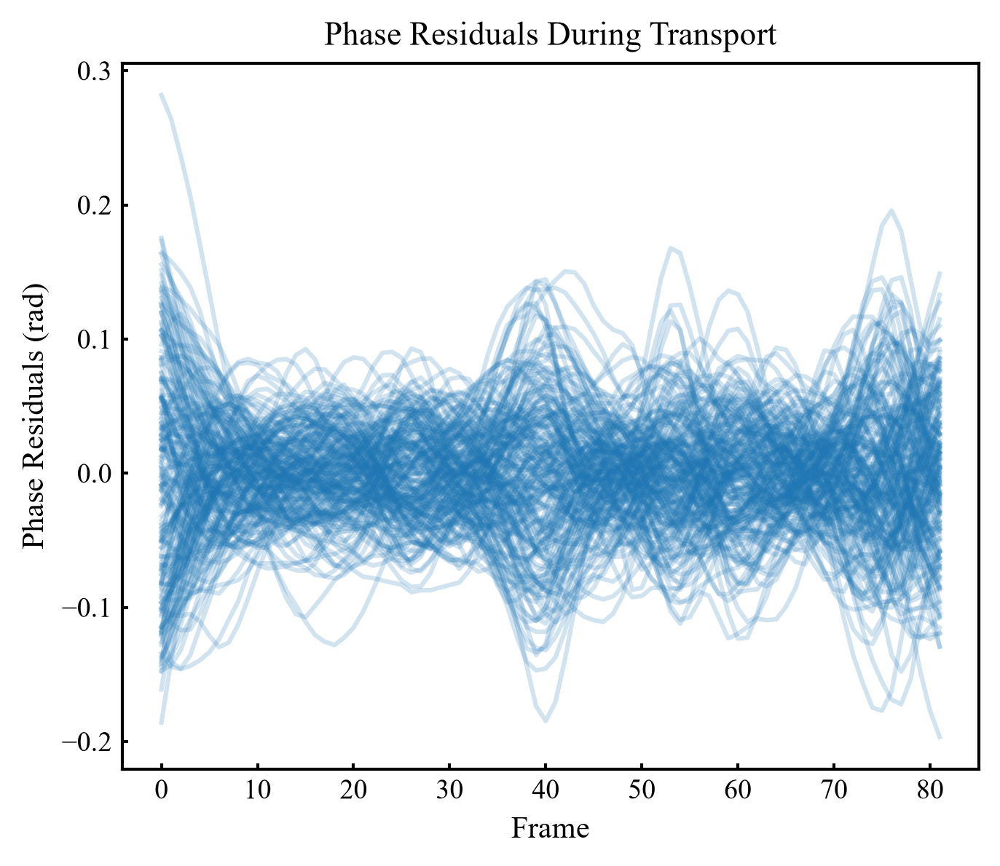

In [44]:
phi_array = phi_foc_array_lpi_0
x_values = []
y_values = []

lin_fit = lambda x, m, b: m * x + b
for n in range(phi_array.shape[1]):
    x = np.arange(phi_array.shape[0]-1)
    y = np.unwrap(phi_array[1:, n])
    popt, pcov = curve_fit(lin_fit, x, y)
    y_fit = lin_fit(x, *popt)
    residuals = y - y_fit
    #plt.plot(x, y, alpha=0.5, color='C0')
    #plt.plot(x, y_fit, alpha=0.8, color='C1')
    plt.plot(x, residuals, alpha=0.2, color='C0')
    x_values.append(x)
    y_values.append(residuals)

#plt.ylim(-np.pi/5, np.pi/5)
plt.xlabel("Frame")
plt.ylabel("Phase Residuals (rad)")
plt.title(f"Phase Residuals During Transport")

x_values_0 = np.array(x_values).flatten()
y_values_0 = np.array(y_values).flatten()

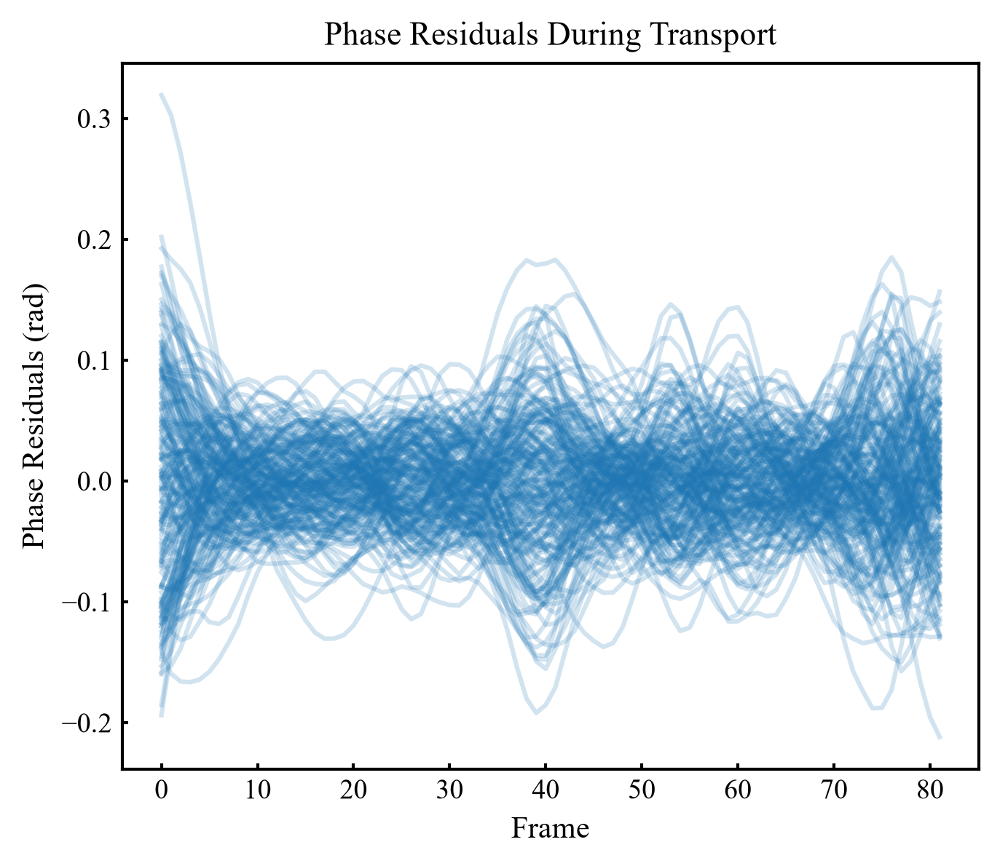

In [45]:
phi_array = phi_foc_array_lpi_2
x_values = []
y_values = []

lin_fit = lambda x, m, b: m * x + b
for n in range(phi_array.shape[1]):
    x = np.arange(phi_array.shape[0]-1)
    y = np.unwrap(phi_array[1:, n])
    popt, pcov = curve_fit(lin_fit, x, y)
    y_fit = lin_fit(x, *popt)
    residuals = y - y_fit
    #plt.plot(x, y, alpha=0.5, color='C0')
    #plt.plot(x, y_fit, alpha=0.8, color='C1')
    plt.plot(x, residuals, alpha=0.2, color='C0')
    x_values.append(x)
    y_values.append(residuals)

#plt.ylim(-np.pi/5, np.pi/5)
plt.xlabel("Frame")
plt.ylabel("Phase Residuals (rad)")
plt.title(f"Phase Residuals During Transport")

x_values_2 = np.array(x_values).flatten()
y_values_2 = np.array(y_values).flatten()

Text(0.5, 0.98, 'Phase Error Over a Rearrangement Sequence')

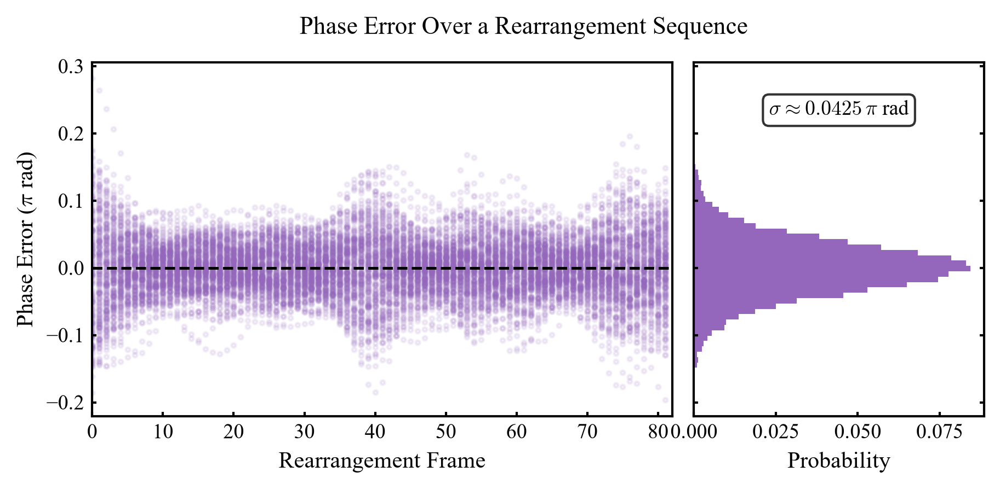

In [46]:

fig_width = 7.0 
fig_height = 2.8

# sharey=True links the y-axes. gridspec_kw sets the width ratios (scatter is wider)
# wspace controls the gap between the two plots. 0.05 pulls them close together.
fig, (ax_scatter, ax_hist) = plt.subplots(
    1, 2, 
    figsize=(fig_width, fig_height), 
    sharey=True, 
    gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.05}
)

# ==============================================================================
# 4. PLOT LEFT PANEL: SCATTER PLOT
# ==============================================================================
# Using hollow circles (facecolor='none') prevents dense clusters from turning into a blob

ax_scatter.scatter(
    x_values_0, y_values_0, facecolor='C4', linewidth=1.0, s=4, label='Individual Traps', alpha=0.1, zorder=0
)

# Add a dashed line representing the ideal target intensity
ax_scatter.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax_scatter.set_xlabel("Rearrangement Frame")
ax_scatter.set_ylabel("Phase Error ($\pi$ rad)")
ax_scatter.set_xlim(0, phi_array.shape[0]-1)

# ==============================================================================
# 5. PLOT RIGHT PANEL: HORIZONTAL HISTOGRAM
# ==============================================================================
# orientation='horizontal' makes the histogram bins align perfectly with the Y-axis
ax_hist.hist(
    y_values_0, 
    bins=60, 
    orientation='horizontal', 
    color='C4', 
    alpha=1.0,
    linewidth=1.0,
    weights=np.ones_like(y_values_0) / len(y_values_0)
)

ax_hist.set_xlabel("Probability")

# Optional: Add a text box to the histogram to show the standard deviation mathematically
stats_text = r"$\sigma \approx {:.4f} \,\pi$ rad".format(np.std(y_values_0))
ax_hist.text(
    0.5, 0.85, stats_text, 
    transform=ax_hist.transAxes, 
    fontsize=9,
    ha='center',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.8)
)

# ==============================================================================
# 6. FINAL FORMATTING & EXPORT
# ==============================================================================
# Ensure the histogram's right side also has inward ticks (sharey=True removes the left ones)
ax_hist.tick_params(axis='y', which='both', labelleft=False, right=True)
plt.suptitle("Phase Error Over a Rearrangement Sequence")

---

In [23]:
"""
Schematic of the SOEH-LPI rearrangement protocol.
172 mm double-column figure, vector PDF, colourblind-safe palette.
"""
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from scipy.optimize import linear_sum_assignment

MM = 1/25.4

# Set True if your machine has a full LaTeX install (needs type1ec.sty, dvipng).
# False uses matplotlib's bundled Computer Modern, which looks the same.
USETEX = False

if USETEX:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
    })
else:
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["cmr10", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.formatter.use_mathtext": True,
        "axes.unicode_minus": False,        # cmr10 has no Unicode minus
    })

plt.rcParams.update({
    "font.size": 7, "axes.linewidth": 0.5,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.10, "pdf.fonttype": 42,
})

# matplotlib default (tab10) palette
BLUE   = "tab:blue"
PURPLE = "C4"
RED    = "C3"
GREY   = "tab:gray"

# ------------------------------------------------------------ geometry
rng = np.random.default_rng(4)
PITCH, NI, NF, FILL = 5.0, 20, 14, 0.58
g = (np.arange(NI)-(NI-1)/2)*PITCH
X, Y = np.meshgrid(g, g, indexing="ij")
sites = np.stack([X.ravel(), Y.ravel()], 1)
occ = rng.random(len(sites)) < FILL
loaded = sites[occ]
t = (np.arange(NF)-(NF-1)/2)*PITCH
TX, TY = np.meshgrid(t, t, indexing="ij")
targets = np.stack([TX.ravel(), TY.ravel()], 1)
ri, ci = linear_sum_assignment(
    np.linalg.norm(loaded[:,None,:]-targets[None,:,:], axis=2)**2)
src, dst = loaded[ri], targets[ci]
drop = loaded[np.setdiff1d(np.arange(len(loaded)), ri)]
LIM = (NI/2)*PITCH + 1.5

MS, MSO = 2.6, 2.6          # marker sizes: filled / open
def frame(ax, tag, title):
    ax.set_xlim(-LIM, LIM); ax.set_ylim(-LIM, LIM); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_linewidth(0.5); s.set_color("#444444")
    ax.text(-0.02, 1.16, tag, transform=ax.transAxes, va="top", ha="left",
            fontsize=7.5)
    ax.set_title(title, fontsize=7, pad=2.5)

fig = plt.figure(figsize=(172*MM, 99*MM))
gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 0.94], hspace=0.18, wspace=0.10,
                      left=0.012, right=0.988, top=0.965, bottom=0.03)
ax = [fig.add_subplot(gs[0, i]) for i in range(4)]

frame(ax[0], "(a)", "stochastic loading")
ax[0].plot(sites[~occ,0], sites[~occ,1], "o", ms=MSO, mfc="none", mec=GREY, mew=.35)
ax[0].plot(loaded[:,0], loaded[:,1], "o", ms=MS, mfc=BLUE, mec="none")

frame(ax[1], "(b)", "match and extinguish")
ax[1].plot(sites[~occ,0], sites[~occ,1], "o", ms=MSO, mfc="none", mec=GREY, mew=.35)
TL = (NF/2)*PITCH
ax[1].add_patch(plt.Rectangle((-TL, -TL), 2*TL, 2*TL, fc=PURPLE, alpha=.10,
                              ec=PURPLE, lw=.6, ls="--", zorder=0))
ax[1].plot(src[:,0], src[:,1], "o", ms=MS, mfc=BLUE, mec="none")

if len(drop):
    ax[1].plot(drop[:,0], drop[:,1], "x", ms=MS*1.8, mec=RED, mew=1.0)

# ------------------------------------------------------------ panel (c)
# every matched atom at its initial site, an arrow to its assigned target for
# those that move, and the targets as open black circles
frame(ax[2], "(c)", "interpolated transport")
ax[2].add_patch(plt.Rectangle((-TL, -TL), 2*TL, 2*TL, fc=PURPLE, alpha=.10,
                              ec=PURPLE, lw=.6, ls="--", zorder=0))
moves = np.linalg.norm(dst - src, axis=1) > 1e-9          # skip atoms already home
for a_, b_ in zip(src[moves], dst[moves]):
    ax[2].annotate("", xy=b_, xytext=a_, zorder=1,
                   arrowprops=dict(arrowstyle="-|>", lw=.35, color="tab:gray",
                                   alpha=.55, mutation_scale=3,
                                   shrinkA=1.5, shrinkB=1.5))
ax[2].plot(dst[:,0], dst[:,1], "o", ms=MSO, mfc="none", mec="k", mew=.45,
           zorder=2)
ax[2].plot(src[:,0], src[:,1], "o", ms=MS, mfc=BLUE, mec="none", zorder=3)

frame(ax[3], "(d)", "defect-free array")
ax[3].plot(sites[:,0], sites[:,1], "o", ms=MSO, mfc="none", mec="#D8D8D8", mew=.3)
ax[3].plot(targets[:,0], targets[:,1], "o", ms=MS, mfc=PURPLE, mec="none")

for i in range(3):
    p0, p1 = ax[i].get_position(), ax[i+1].get_position()
    fig.add_artist(FancyArrowPatch(((p0.x1+p1.x0)/2-0.008, (p0.y0+p0.y1)/2),
                                   ((p0.x1+p1.x0)/2+0.008, (p0.y0+p0.y1)/2),
                                   transform=fig.transFigure, arrowstyle="-|>",
                                   mutation_scale=7, lw=.8, color="k"))

# ------------------------------------------------------------ panel (e)
axe = fig.add_subplot(gs[1, :]); axe.axis("off")
axe.set_xlim(0, 1); axe.set_ylim(0, 1.06)

def box(x, y, w, h, txt, fc, ec, fs=6.3, gaps=None):
    """Draw a rounded box with centred text.
 
    txt  : string with "\n" line breaks.
    gaps : optional list of vertical gaps between successive lines, in
           panel-(e) data units (the panel is 1.06 tall). If given, each line
           is drawn as its own text object so individual gaps can be tuned;
           otherwise the whole string is drawn at uniform linespacing=1.6.
    """
    axe.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.006",
                                 lw=.7, fc=fc, ec=ec, zorder=2,
                                 transform=axe.transData))
    if gaps is None:
        axe.text(x+w/2, y+h/2, txt, ha="center", va="center", fontsize=fs,
                 zorder=3, linespacing=1.6)
        return
    lines = txt.split("\n")
    assert len(gaps) == len(lines) - 1, "need one gap per pair of lines"
    offsets = np.concatenate([[0.0], np.cumsum(gaps)])
    y_top = y + h/2 + offsets[-1]/2           # centre the block vertically
    for line, dy in zip(lines, offsets):
        axe.text(x+w/2, y_top - dy, line, ha="center", va="center",
                 fontsize=fs, zorder=3)

W   = [0.162, 0.178, 0.205, 0.215, 0.120]
gap = 0.0215
span = sum(W) + gap*(len(W)-1)
x0 = (1.0 - span)/2.0
Xs, x = [], x0
for w in W:
    Xs.append(x); x += w + gap

YB, HB = 0.545, 0.375

box(Xs[0], YB, W[0], HB, "endpoint holograms\n"
    r"$\{w_n^{0},\theta_n^{0},\mathbf{r}_n^{0}\}$" "\n"
    r"$\{w_n^{K},\theta_n^{K},\mathbf{r}_n^{K}\}$", "#F0F0F0", GREY,
    gaps=[0.115, 0.115])
box(Xs[1], YB, W[1], HB, "match, extinguish\n"
    r"$w_n\rightarrow0$ if unmatched" "\n"
    r"re-equalise ($\gtrsim\!10$ iter.)", "#F7E3E3", RED)
box(Xs[2], YB, W[2], HB, "interpolate at step $s$\n"
    r"$\mathbf{r}_n^p=(1-s)\mathbf{r}_n^{0}+s\,\mathbf{r}_n^{K}$" "\n"
    r"$\theta_n(s)=\theta_n^{0}+s\,\Delta\theta_n$", "#DCE9F5", BLUE)
box(Xs[3], YB, W[3], HB, "superimpose\n"
    r"$\Phi=\arg\sum_n w_n e^{i(\mathbf{k}_n\cdot\mathbf{r}'+\theta_n)}$" "\n"
    r"$\mathbf{k}_n=(2\pi\mathcal{M}/\lambda f)\,\mathbf{r}_n$", "#DCE9F5", BLUE,
    gaps=[0.115, 0.115])
box(Xs[4], YB, W[4], HB, "display\non SLM", "#F0F0F0", GREY)

for i in range(4):
    axe.add_patch(FancyArrowPatch((Xs[i]+W[i]+0.004, YB+HB/2),
                                  (Xs[i+1]-0.004, YB+HB/2),
                                  arrowstyle="-|>", mutation_scale=7, lw=.8,
                                  color="k", zorder=1))

# evaluate-traps box below "superimpose"
WE, HE = 0.255, 0.330
YE = 0.092
XE = Xs[3] + W[3]/2 - WE/2
box(XE, YE, WE, HE, "evaluate traps and update weights\n"
    r"$U_n=\frac{1}{M}G^{T}\mathbf{U}_{\mathrm{SLM}}$" "\n"
    r"$w_n\leftarrow w_n\,(\langle I\rangle/I_n)^{\alpha}$", "#EFE3F0", PURPLE,
    gaps=[0.115, 0.115])

x_down = Xs[3] + W[3]*0.32
x_up   = Xs[3] + W[3]*0.68
axe.annotate("", xy=(x_down, YE+HE+0.004), xytext=(x_down, YB-0.004),
             arrowprops=dict(arrowstyle="-|>", lw=.8, color="k",
                             mutation_scale=7, shrinkA=0, shrinkB=0))
axe.annotate("", xy=(x_up, YB-0.004), xytext=(x_up, YE+HE+0.004),
             arrowprops=dict(arrowstyle="-|>", lw=.8, color=RED,
                             mutation_scale=7, shrinkA=0, shrinkB=0))

axe.text(x_up+0.011, (YB + YE+HE)/2 -0.02, r"$w_n$", ha="left", va="center",
         fontsize=6.3, color=RED)
axe.text(XE+WE/2, YE-0.030,
         r"weight equalisation (1 iter.),  $\theta_n$ held fixed",
         ha="center", va="top", fontsize=6.3, color=RED)

def routed(x_from, x_to, y_rail, y_box, colour, lw=0.8):
    axe.plot([x_from, x_from], [y_box, y_rail], color=colour, lw=lw, zorder=1)
    axe.plot([x_from, x_to], [y_rail, y_rail], color=colour, lw=lw, zorder=1)
    axe.annotate("", xy=(x_to, y_box), xytext=(x_to, y_rail),
                 arrowprops=dict(arrowstyle="-|>", lw=lw, color=colour,
                                 mutation_scale=7, shrinkA=0, shrinkB=0))

routed(Xs[4]+W[4]/2, Xs[2]+W[2]/2, 0.975, YB+HB, "k")
axe.text((Xs[2]+W[2]/2 + Xs[4]+W[4]/2)/2, 0.993,
         r"repeat for $s=0,\,1/K,\,\dots,\,1$",
         ha="center", va="bottom", fontsize=6.3, style="italic")

# stage brackets: once per cycle vs once per frame
def bracket(xa, xb, y, label):
    axe.plot([xa, xa, xb, xb], [y+0.035, y, y, y+0.035], color="0.45",
             lw=.6, zorder=1, clip_on=False)
    axe.text(xa+0.018, y-0.026, label, ha="left", va="top",
             fontsize=6.0, color="0.35")

#bracket(Xs[0], Xs[1]+W[1], 0.500, "once per rearrangement")
bracket(Xs[2], Xs[4]+W[4], 0.500, "once per frame")

axe.text(0.002, 0.993, "(e)", fontsize=7.5, va="bottom")

fig.savefig("fig_protocol.pdf")
print(f"loaded {occ.sum()},  matched {len(src)},  moving {moves.sum()},  "
      f"stationary {(~moves).sum()},  extinguished {len(drop)}")

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


loaded 209,  matched 196,  moving 193,  stationary 3,  extinguished 13


---

## Combined Plot

In [49]:
MM = 1/25.4

def plot_trap_intensity_distribution(ax, I_foc_array_lpi_0, I_foc_array_lpi_1, I_foc_array_lpi_2, I_foc_array_lpi_3):
    ax.fill_between(np.arange(I_foc_array_lpi_3.shape[0]-1),
                    np.min(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]), axis=1),
                    np.max(I_foc_array_lpi_3[1:, :]/np.mean(I_foc_array_lpi_3[-1, :]), axis=1),
                    color='C4', alpha=0.2, label=r'$w_n=1$', zorder=1)

    ax.fill_between(np.arange(I_foc_array_lpi_0.shape[0]-1),
                    np.min(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]), axis=1),
                    np.max(I_foc_array_lpi_0[1:, :]/np.mean(I_foc_array_lpi_0[-1, :]), axis=1),
                    color='C1', alpha=0.2, label='0 it', zorder=0)

    ax.fill_between(np.arange(I_foc_array_lpi_1.shape[0]-1),
                    np.min(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]), axis=1),
                    np.max(I_foc_array_lpi_1[1:, :]/np.mean(I_foc_array_lpi_1[-1, :]), axis=1),
                    color='C0', alpha=0.4, label='1 it', zorder=2)

    ax.fill_between(np.arange(I_foc_array_lpi_2.shape[0]-1),
                    np.min(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]), axis=1),
                    np.max(I_foc_array_lpi_2[1:, :]/np.mean(I_foc_array_lpi_2[-1, :]), axis=1),
                    color='C3', alpha=0.8, label='2 it', zorder=3)
    ax.set_ylim(None, 2.0)
    ax.set_xlabel("Rearrangement Frame")
    ax.set_ylabel("Norm. Trap Intensity")
    ax.legend(loc="upper left", ncol=4)

def plot_phase_error_distribution(ax_scatter, ax_hist, phi_array, x_values_0, y_values_0):
    ax_scatter.scatter(
        x_values_0, y_values_0, facecolor='C4', linewidth=1.0, s=4, label='Individual Traps', alpha=0.2, zorder=0
    )

    ax_scatter.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
    ax_scatter.set_xlabel("Rearrangement Frame")
    ax_scatter.set_ylabel("Phase Error (rad)")
    ax_scatter.set_xlim(0, phi_array.shape[0]-1)

    ax_hist.hist(
        y_values_0, 
        bins=60, 
        orientation='horizontal', 
        color='C4', 
        alpha=1.0,
        linewidth=1.0,
        weights=np.ones_like(y_values_0) / len(y_values_0)
    )
    ax_hist.set_xlabel("Probability")

    stats_text = r"$\sigma_\varepsilon \approx {:.4f}$ rad".format( 0.0138 * np.pi )
    ax_hist.text(
        0.5, 0.85, stats_text, 
        transform=ax_hist.transAxes, 
        fontsize=9,
        ha='center',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.8)
    )
    ax_hist.tick_params(axis='y', which='both', labelleft=False, right=True)

def plot_equalisation_iterations(ax1, num_it_list, std_list, std_3):
    ax2 = ax1.twinx()
    plot1 = ax1.plot(num_it_list, std_list, marker='o', color='C0', label='Non-uniformity')
    plot2 = ax2.plot(num_it_list, std_residuals_list, marker='s', color='C4', label='Std. phase error')

    ax1.set_xlabel('No. of Equalization Iterations')
    ax1.set_ylabel(r'Non-Uniformity $\sigma_I/\langle I \rangle$')
    ax2.set_ylabel(r'Std. Phase Error $\sigma_\varepsilon$(rad)')
    ax1.legend(handles=[plot1[0], plot2[0]], loc='right')
    ax1.set_yscale('log')

def panel_tag(ax, tag, x=-0.13, y=1.02):
    ax.text(x, y, tag, transform=ax.transAxes, fontsize=7.5, va="bottom",
            ha="left")

In [50]:
fig = plt.figure(figsize=(172*MM, 108*MM))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.08], width_ratios=[2, 0.9, 1.35],
                        hspace=0.3, wspace=0.06, left=0.07, right=0.985,
                        top=0.955, bottom=0.085)

ax_s = fig.add_subplot(gs[0, 0:2])
ax_h = fig.add_subplot(gs[0, 2], sharey=ax_s)

sig = plot_phase_error_distribution(ax_s, ax_h, phi_array, x_values_0, y_values_0)
panel_tag(ax_s, "(a)", x=-0.075)

gs2 = gs[1, :].subgridspec(1, 2, width_ratios=[1.55, 1], wspace=0.22)

ax_b = fig.add_subplot(gs2[0]); ax_i = fig.add_subplot(gs2[1])
stats = plot_trap_intensity_distribution(ax_b, I_foc_array_lpi_0, I_foc_array_lpi_1, I_foc_array_lpi_2, I_foc_array_lpi_3)
plot_equalisation_iterations(ax_i, num_it_list, std_list, std_3)
panel_tag(ax_b, "(b)", x=-0.12); panel_tag(ax_i, "(c)", x=-0.20)
fig.savefig("..\\plotting\\fig_numerics.pdf"); plt.close(fig)

---
## Survival Probabilities

In [31]:
from scipy.stats import beta

def wilson(k, n, z=1.0):                      # z = 1 (68.27%), 1.96 (95%)
    p = k/n; d = 1 + z*z/n
    c = (p + z*z/(2*n))/d
    h = z/d*np.sqrt(p*(1-p)/n + z*z/(4*n*n))
    return c-h, c+h

def clopper_pearson(k, n, cl=0.6827):
    a = 1-cl
    lo = 0.0 if k == 0 else beta.ppf(a/2, k, n-k+1)
    hi = 1.0 if k == n else beta.ppf(1-a/2, k+1, n-k)
    return lo, hi

In [18]:
date = "12Aug26"
DataManager.list_datasets(date);

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\12Aug26:
  - imaging_survival_40ms/
  - imaging_survival_50ms/
  - rearrangement_10x10_7x7/
  - rearrangement_step_size_scans/


In [19]:
date = "12Aug26"
DataManager.list_datasets(date);
dataset = DataManager.load_dataset(date, "imaging_survival_50ms")

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\12Aug26:
  - imaging_survival_40ms/
  - imaging_survival_50ms/
  - rearrangement_10x10_7x7/
  - rearrangement_step_size_scans/
Loading dataset: imaging_survival_50ms
Contents:
  Files:
    - final_imgs.pkl
    - initial_imgs.pkl
----------------------------------------


In [20]:
imgs0 = dataset.pickles.get('initial_imgs.pkl')
imgs1 = dataset.pickles.get('final_imgs.pkl')

Looking for trap sites...
100 Atoms Detected.


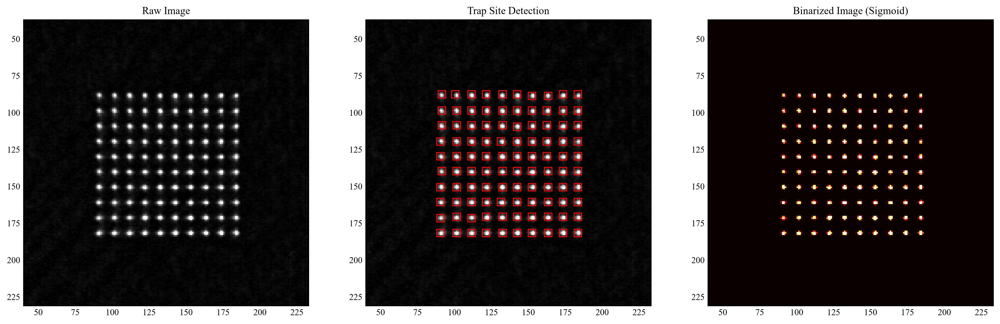

Trap (0) Loading Probability : 53.80 %
Trap (1) Loading Probability : 49.40 %
Trap (2) Loading Probability : 59.40 %
Trap (3) Loading Probability : 55.60 %
Trap (4) Loading Probability : 51.20 %
Trap (5) Loading Probability : 59.80 %
Trap (6) Loading Probability : 59.20 %
Trap (7) Loading Probability : 52.60 %
Trap (8) Loading Probability : 57.40 %
Trap (9) Loading Probability : 56.40 %
Trap (10) Loading Probability : 55.80 %
Trap (11) Loading Probability : 59.80 %
Trap (12) Loading Probability : 55.80 %
Trap (13) Loading Probability : 57.60 %
Trap (14) Loading Probability : 58.40 %
Trap (15) Loading Probability : 56.40 %
Trap (16) Loading Probability : 55.40 %
Trap (17) Loading Probability : 59.60 %
Trap (18) Loading Probability : 54.20 %
Trap (19) Loading Probability : 58.40 %
Trap (20) Loading Probability : 58.00 %
Trap (21) Loading Probability : 56.60 %
Trap (22) Loading Probability : 59.20 %
Trap (23) Loading Probability : 55.40 %
Trap (24) Loading Probability : 55.20 %
Trap (25) 

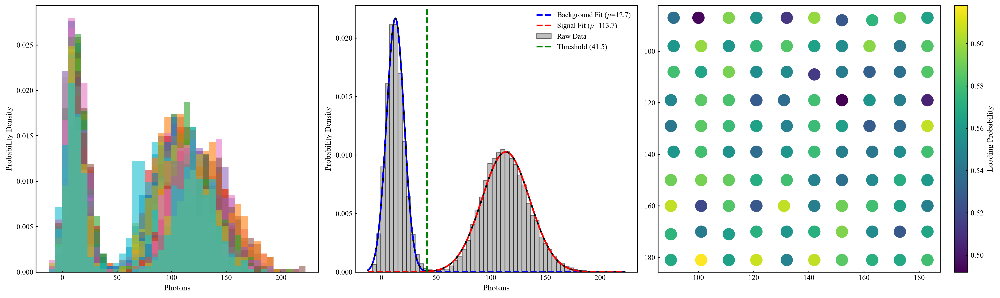

In [21]:
window, feature_size = 5, 10
imgs_n_mean = imgs0.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, 100, detection_step=50)
an.visualize_results(imgs_n_mean_filtered, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs0]
photon_rates_1, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, threshold_detection=True, threshold=30, window_size=window, binning=60)

Trap (0) Loading Probability : 54.00 %
Trap (1) Loading Probability : 49.40 %
Trap (2) Loading Probability : 59.40 %
Trap (3) Loading Probability : 55.60 %
Trap (4) Loading Probability : 51.40 %
Trap (5) Loading Probability : 59.80 %
Trap (6) Loading Probability : 59.20 %
Trap (7) Loading Probability : 52.80 %
Trap (8) Loading Probability : 57.40 %
Trap (9) Loading Probability : 56.40 %
Trap (10) Loading Probability : 56.00 %
Trap (11) Loading Probability : 60.40 %
Trap (12) Loading Probability : 55.80 %
Trap (13) Loading Probability : 57.60 %
Trap (14) Loading Probability : 58.40 %
Trap (15) Loading Probability : 56.20 %
Trap (16) Loading Probability : 55.40 %
Trap (17) Loading Probability : 59.40 %
Trap (18) Loading Probability : 54.20 %
Trap (19) Loading Probability : 58.40 %
Trap (20) Loading Probability : 58.00 %
Trap (21) Loading Probability : 56.60 %
Trap (22) Loading Probability : 59.40 %
Trap (23) Loading Probability : 55.60 %
Trap (24) Loading Probability : 54.80 %
Trap (25) 

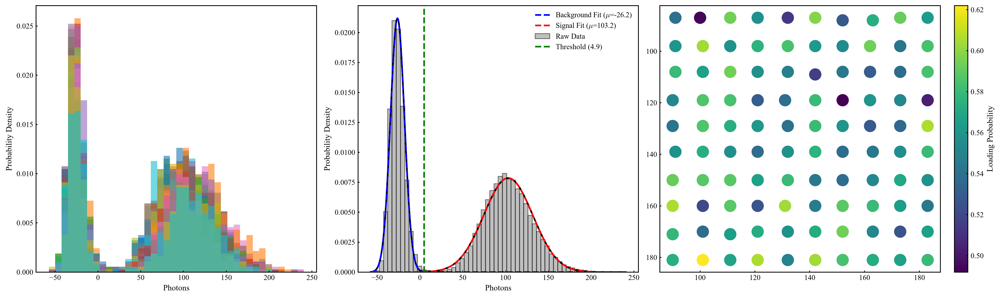

In [22]:
psf_window = 9

scorer = an.SiteScorer.from_images(imgs0, grid_positions_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs0, grid_positions_1, scorer=scorer, threshold_detection=True, binning=60)
scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

In [23]:
N_samples = photons.flatten().shape[0]
mean_filling_fraction = np.mean(loading_probabilities)

wilson_lo, wilson_hi = wilson(mean_filling_fraction*N_samples, N_samples)
clopper_pearson_lo, clopper_pearson_hi = clopper_pearson(mean_filling_fraction*N_samples, N_samples)

print(f"Mean filling fraction: {mean_filling_fraction:.6f}")
print(f"Wilson lower: {wilson_lo:.6f}, upper: {wilson_hi:.6f}")
print(f"Clopper-Pearson lower: {clopper_pearson_lo:.6f}, upper: {clopper_pearson_hi:.6f}")

Mean filling fraction: 0.562860
Wilson lower: 0.560640, upper: 0.565077
Clopper-Pearson lower: 0.560630, upper: 0.565087


Looking for trap sites...
100 Atoms Detected.


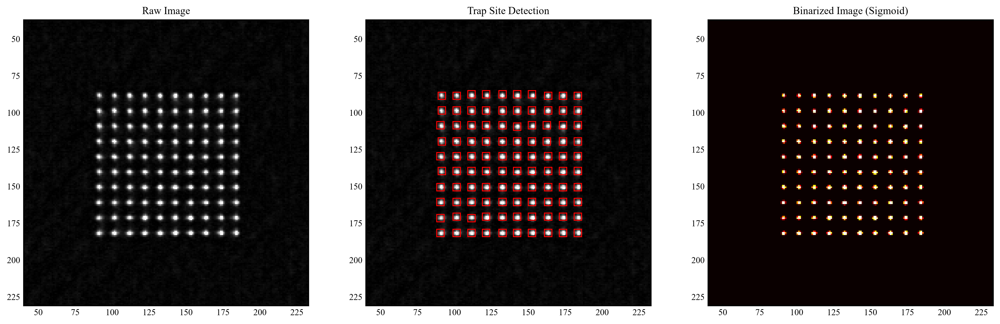

Trap (0) Loading Probability : 58.40 %
Trap (1) Loading Probability : 54.20 %
Trap (2) Loading Probability : 48.40 %
Trap (3) Loading Probability : 58.20 %
Trap (4) Loading Probability : 52.80 %
Trap (5) Loading Probability : 48.00 %
Trap (6) Loading Probability : 50.60 %
Trap (7) Loading Probability : 55.60 %
Trap (8) Loading Probability : 55.80 %
Trap (9) Loading Probability : 55.20 %
Trap (10) Loading Probability : 54.20 %
Trap (11) Loading Probability : 58.60 %
Trap (12) Loading Probability : 54.80 %
Trap (13) Loading Probability : 56.40 %
Trap (14) Loading Probability : 57.20 %
Trap (15) Loading Probability : 55.60 %
Trap (16) Loading Probability : 53.80 %
Trap (17) Loading Probability : 58.20 %
Trap (18) Loading Probability : 53.60 %
Trap (19) Loading Probability : 58.20 %
Trap (20) Loading Probability : 56.40 %
Trap (21) Loading Probability : 55.40 %
Trap (22) Loading Probability : 57.40 %
Trap (23) Loading Probability : 52.60 %
Trap (24) Loading Probability : 52.80 %
Trap (25) 

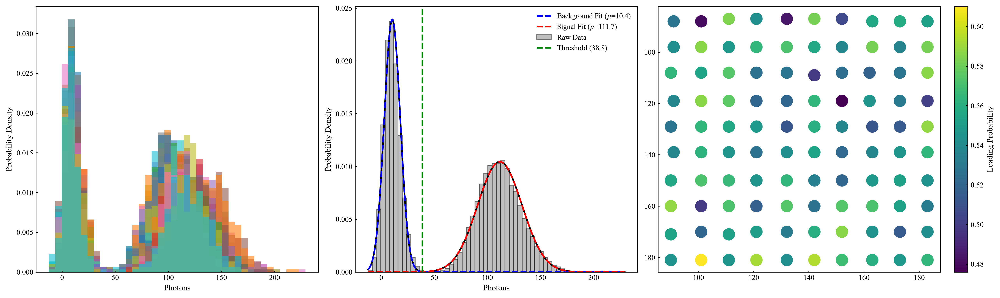

In [12]:
window, feature_size = 5, 10
imgs_n_mean = imgs1.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, 100, detection_step=50)
an.visualize_results(imgs_n_mean_filtered, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates_1, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, threshold_detection=True, threshold=30, window_size=window, binning=60)

Trap (0) Loading Probability : 58.40 %
Trap (1) Loading Probability : 54.20 %
Trap (2) Loading Probability : 48.80 %
Trap (3) Loading Probability : 58.40 %
Trap (4) Loading Probability : 53.00 %
Trap (5) Loading Probability : 48.00 %
Trap (6) Loading Probability : 50.60 %
Trap (7) Loading Probability : 55.60 %
Trap (8) Loading Probability : 55.80 %
Trap (9) Loading Probability : 55.20 %
Trap (10) Loading Probability : 54.20 %
Trap (11) Loading Probability : 59.00 %
Trap (12) Loading Probability : 54.80 %
Trap (13) Loading Probability : 56.20 %
Trap (14) Loading Probability : 57.20 %
Trap (15) Loading Probability : 55.60 %
Trap (16) Loading Probability : 53.80 %
Trap (17) Loading Probability : 57.80 %
Trap (18) Loading Probability : 53.80 %
Trap (19) Loading Probability : 58.40 %
Trap (20) Loading Probability : 56.60 %
Trap (21) Loading Probability : 55.40 %
Trap (22) Loading Probability : 57.40 %
Trap (23) Loading Probability : 52.80 %
Trap (24) Loading Probability : 52.60 %
Trap (25) 

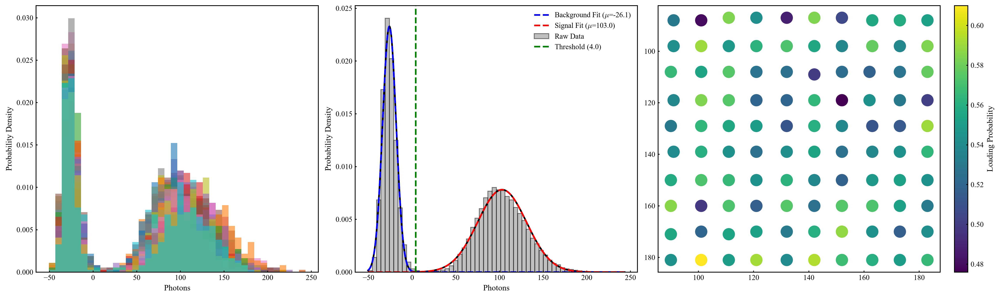

In [13]:
psf_window = 9

scorer = an.SiteScorer.from_images(imgs1, grid_positions_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs1, grid_positions_1, scorer=scorer, threshold_detection=True, binning=60)
scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

In [14]:
N_samples = photons.flatten().shape[0]
mean_filling_fraction = np.mean(loading_probabilities)

wilson_lo, wilson_hi = wilson(mean_filling_fraction*N_samples, N_samples)
clopper_pearson_lo, clopper_pearson_hi = clopper_pearson(mean_filling_fraction*N_samples, N_samples)

print(f"Mean filling fraction: {mean_filling_fraction:.6f}")
print(f"Wilson lower: {wilson_lo:.6f}, upper: {wilson_hi:.6f}")
print(f"Clopper-Pearson lower: {clopper_pearson_lo:.6f}, upper: {clopper_pearson_hi:.6f}")

Mean filling fraction: 0.547420
Wilson lower: 0.545193, upper: 0.549645
Clopper-Pearson lower: 0.545183, upper: 0.549655


In [27]:
out = an.extract_survival_probability(imgs0, imgs1, grid_positions_1, threshold='auto', window_size=5)
N_samples = photons.flatten().shape[0]
print(f"Survival probability: {out*100:.6f} % | Samples: {N_samples}")

Survival probability: 97.006464 % | Samples: 50000


---
## Histograms

In [3]:
date = "12Aug26"
DataManager.list_datasets(date);

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\12Aug26:
  - imaging_survival_40ms/
  - imaging_survival_50ms/
  - rearrangement_10x10_7x7/
  - rearrangement_step_size_scans/


In [4]:
date = "12Aug26"
DataManager.list_datasets(date);
dataset = DataManager.load_dataset(date, "rearrangement_10x10_7x7")

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\12Aug26:
  - imaging_survival_40ms/
  - imaging_survival_50ms/
  - rearrangement_10x10_7x7/
  - rearrangement_step_size_scans/
Loading dataset: rearrangement_10x10_7x7

--- Experimental Info ---

Dataset Title: rearrangement_10x10_7x7
Date: 2026-08-12 12:34:52

    50 ms time slot given for rearrangement with a baseline survival probability of 0.969698.
    Rearrangement parameters: d0 = 0.5, threshold = 5456.5652 photons, profile = linear, window_size = 5, feature_size = 10.
    Occupancy extraction using the PSF method.

----------------------------------------
Contents:
  Subdirectories:
    - final_images/
    - initial_images/
  Files:
    - experiment_info.txt
    - timing_and_images.pkl
----------------------------------------


In [5]:
data_pkl = dataset.pickles.get('timing_and_images.pkl')
data_pkl.keys()
imgs0 = data_pkl['imgs0']
imgs1 = data_pkl['imgs1']

Looking for trap sites...
100 Atoms Detected.


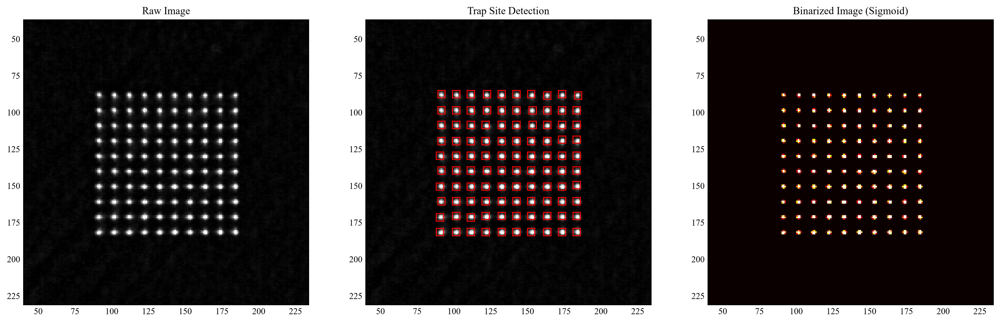

Trap (0) Loading Probability : 55.50 %
Trap (1) Loading Probability : 54.10 %
Trap (2) Loading Probability : 57.10 %
Trap (3) Loading Probability : 55.90 %
Trap (4) Loading Probability : 53.90 %
Trap (5) Loading Probability : 55.50 %
Trap (6) Loading Probability : 52.80 %
Trap (7) Loading Probability : 54.10 %
Trap (8) Loading Probability : 49.00 %
Trap (9) Loading Probability : 53.00 %
Trap (10) Loading Probability : 56.00 %
Trap (11) Loading Probability : 53.60 %
Trap (12) Loading Probability : 55.60 %
Trap (13) Loading Probability : 53.60 %
Trap (14) Loading Probability : 55.30 %
Trap (15) Loading Probability : 54.90 %
Trap (16) Loading Probability : 55.10 %
Trap (17) Loading Probability : 53.90 %
Trap (18) Loading Probability : 57.10 %
Trap (19) Loading Probability : 56.00 %
Trap (20) Loading Probability : 55.40 %
Trap (21) Loading Probability : 55.40 %
Trap (22) Loading Probability : 54.90 %
Trap (23) Loading Probability : 53.10 %
Trap (24) Loading Probability : 53.30 %
Trap (25) 

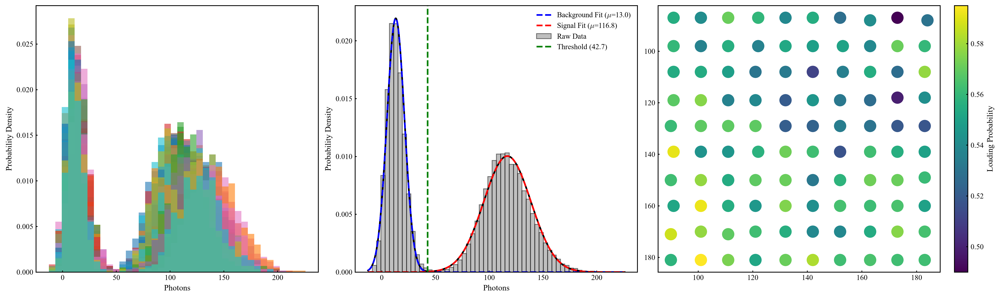

In [6]:
window, feature_size = 5, 10
imgs_n_mean = imgs0.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, 100, detection_step=50)
an.visualize_results(imgs_n_mean_filtered, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs0]
photon_rates_1, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, threshold_detection=True, threshold=30, window_size=window, binning=60)

Trap (0) Loading Probability : 55.70 %
Trap (1) Loading Probability : 54.20 %
Trap (2) Loading Probability : 57.00 %
Trap (3) Loading Probability : 56.00 %
Trap (4) Loading Probability : 54.00 %
Trap (5) Loading Probability : 55.70 %
Trap (6) Loading Probability : 52.70 %
Trap (7) Loading Probability : 54.20 %
Trap (8) Loading Probability : 49.00 %
Trap (9) Loading Probability : 53.00 %
Trap (10) Loading Probability : 56.10 %
Trap (11) Loading Probability : 53.60 %
Trap (12) Loading Probability : 55.80 %
Trap (13) Loading Probability : 53.90 %
Trap (14) Loading Probability : 55.40 %
Trap (15) Loading Probability : 54.90 %
Trap (16) Loading Probability : 55.40 %
Trap (17) Loading Probability : 54.00 %
Trap (18) Loading Probability : 57.20 %
Trap (19) Loading Probability : 56.20 %
Trap (20) Loading Probability : 55.50 %
Trap (21) Loading Probability : 55.50 %
Trap (22) Loading Probability : 54.90 %
Trap (23) Loading Probability : 52.90 %
Trap (24) Loading Probability : 53.20 %
Trap (25) 

Trap (65) Loading Probability : 56.80 %
Trap (66) Loading Probability : 53.00 %
Trap (67) Loading Probability : 55.70 %
Trap (68) Loading Probability : 57.20 %
Trap (69) Loading Probability : 57.10 %
Trap (70) Loading Probability : 55.50 %
Trap (71) Loading Probability : 59.20 %
Trap (72) Loading Probability : 55.40 %
Trap (73) Loading Probability : 54.60 %
Trap (74) Loading Probability : 57.60 %
Trap (75) Loading Probability : 54.20 %
Trap (76) Loading Probability : 56.40 %
Trap (77) Loading Probability : 56.20 %
Trap (78) Loading Probability : 56.60 %
Trap (79) Loading Probability : 55.00 %
Trap (80) Loading Probability : 57.50 %
Trap (81) Loading Probability : 56.10 %
Trap (82) Loading Probability : 55.70 %
Trap (83) Loading Probability : 53.80 %
Trap (84) Loading Probability : 54.00 %
Trap (85) Loading Probability : 55.50 %
Trap (86) Loading Probability : 57.60 %
Trap (87) Loading Probability : 56.60 %
Trap (88) Loading Probability : 59.00 %
Trap (89) Loading Probability : 56.90 %


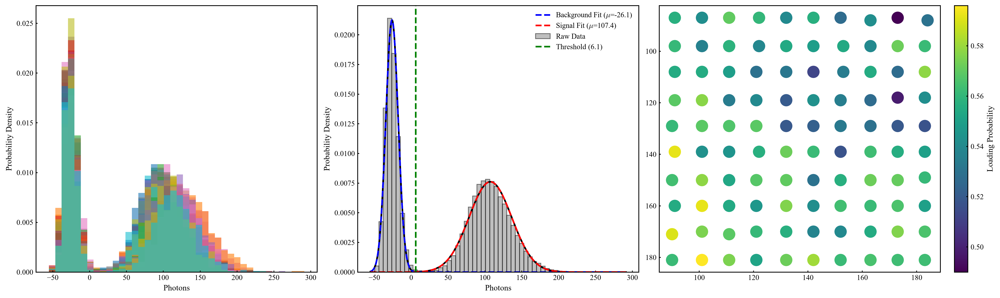

In [7]:
psf_window = 9

scorer = an.SiteScorer.from_images(imgs0, grid_positions_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs0, grid_positions_1, scorer=scorer, threshold_detection=True, binning=60)
scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

(array([4.4000e+01, 8.3400e+02, 6.0010e+03, 1.3713e+04, 1.3186e+04,
        7.3720e+03, 2.6580e+03, 7.5500e+02, 1.8900e+02, 8.3000e+01,
        4.6000e+01, 5.1000e+01, 8.6000e+01, 2.2300e+02, 3.5800e+02,
        7.1100e+02, 1.0760e+03, 1.8780e+03, 2.7830e+03, 3.7060e+03,
        4.5100e+03, 5.1710e+03, 5.4320e+03, 5.3880e+03, 5.0280e+03,
        4.3920e+03, 3.7820e+03, 3.0020e+03, 2.3330e+03, 1.7110e+03,
        1.1680e+03, 8.1000e+02, 5.8800e+02, 3.9300e+02, 2.2200e+02,
        1.2700e+02, 8.1000e+01, 3.9000e+01, 3.7000e+01, 1.4000e+01,
        9.0000e+00, 5.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([-5.52609901e+01, -4.83294373e+01, -4.13978882e+01, -3.44663353e+01,
        -2.75347824e+01, -2.06032295e+01, -1.36716805e+01, -6.74012756e+00,
         1.91425323e-01,  7.12297821e+00,  1.40545311e+01,  2.09860802e+01,
         2.79176292e+01,  3.48491859e+01,  4.17807350e+01,  4.87122917e+01,
         5.564

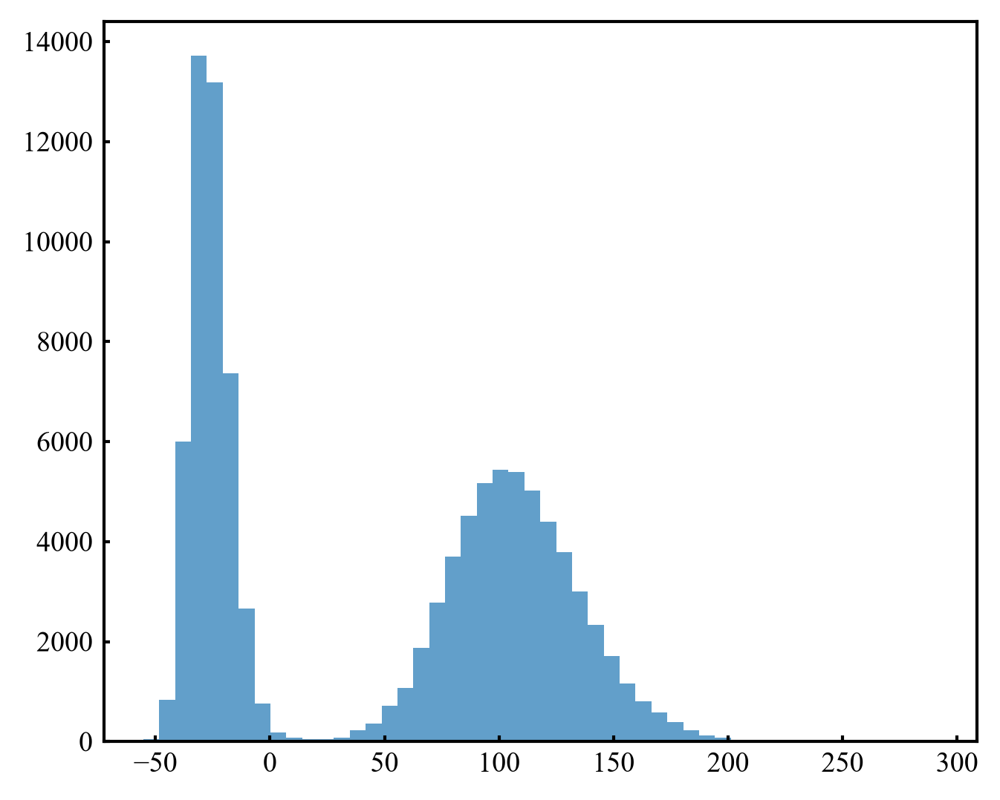

In [8]:
plt.hist(photons.flatten(), bins=50, color='C0', alpha=0.7)

In [9]:
"""
Overlap between the background and single-atom peaks of a photon-count
histogram, from a two-component Gaussian mixture fit.

Quantities returned (all as fractions; multiply by 100 for %):

  eps_fp    false-positive rate: P(count > t | empty)
  eps_fn    false-negative rate: P(count <= t | occupied)
  infidelity  (eps_fp + eps_fn)/2, i.e. 1 - detection fidelity
  bayes_error misclassification rate weighted by the filling fraction,
              = integral of min(w0 f0, w1 f1) for the optimal threshold
  ovl       overlap coefficient of the two normalised Gaussians,
              = integral of min(f0, f1); independent of the filling fraction
              and of any threshold (OVL = 2 * equal-error rate when sigmas match)

The threshold t is where the two weighted Gaussians cross (the threshold that
minimises the total number of misclassified sites), unless one is supplied.
"""
import numpy as np
from scipy.stats import norm
from scipy.integrate import trapezoid
from sklearn.mixture import GaussianMixture


def fit_two_gaussians(counts, seed=0):
    """Fit a 2-component GMM; return (w, mu, sigma) sorted so index 0 = background."""
    x = np.asarray(counts, float).reshape(-1, 1)
    gm = GaussianMixture(n_components=2, covariance_type="full",
                         n_init=5, random_state=seed).fit(x)
    w = gm.weights_
    mu = gm.means_.ravel()
    sd = np.sqrt(gm.covariances_.ravel())
    order = np.argsort(mu)
    return w[order], mu[order], sd[order]


def crossing_threshold(w, mu, sd, weighted=True):
    """Count at which w0*N(mu0,s0) = w1*N(mu1,s1), between the two means.
    weighted=False uses w0 = w1 (equal-prior crossing)."""
    w0, w1 = (w if weighted else (0.5, 0.5))
    (m0, m1), (s0, s1) = mu, sd
    a = 1/(2*s1**2) - 1/(2*s0**2)
    b = m0/s0**2 - m1/s1**2
    c = m1**2/(2*s1**2) - m0**2/(2*s0**2) + np.log(w0*s1/(w1*s0))
    if abs(a) < 1e-12:                         # equal widths: linear equation
        return -c/b
    roots = np.roots([a, b, c])
    roots = roots[np.isreal(roots)].real
    between = roots[(roots > m0) & (roots < m1)]
    if len(between) == 0:
        raise ValueError("peaks too poorly separated: no crossing between the means")
    return between[0]


def overlap_stats(counts, threshold=None, weighted=True, n_boot=0, seed=0):
    """Fit, then compute the overlap quantities. With n_boot > 0, also return
    bootstrap 1-sigma uncertainties (resampling counts with replacement)."""
    w, mu, sd = fit_two_gaussians(counts, seed)
    t = crossing_threshold(w, mu, sd, weighted) if threshold is None else threshold

    eps_fp = norm.sf(t, mu[0], sd[0])
    eps_fn = norm.cdf(t, mu[1], sd[1])

    # integrals over a fine grid spanning both peaks
    xg = np.linspace(mu[0] - 10*sd[0], mu[1] + 10*sd[1], 200_001)
    f0, f1 = norm.pdf(xg, mu[0], sd[0]), norm.pdf(xg, mu[1], sd[1])
    ovl = trapezoid(np.minimum(f0, f1), xg)
    bayes = trapezoid(np.minimum(w[0]*f0, w[1]*f1), xg)

    out = dict(threshold=t, weights=w, means=mu, sigmas=sd,
               eps_fp=eps_fp, eps_fn=eps_fn,
               infidelity=0.5*(eps_fp + eps_fn),
               bayes_error=bayes, ovl=ovl,
               filling=np.mean(np.asarray(counts) > t))

    if n_boot:
        rng = np.random.default_rng(seed)
        keys = ["eps_fp", "eps_fn", "infidelity", "bayes_error", "ovl", "threshold"]
        boot = {k: [] for k in keys}
        c = np.asarray(counts)
        for i in range(n_boot):
            r = overlap_stats(rng.choice(c, c.size, replace=True), threshold,
                              weighted, 0, seed=i+1)
            for k in keys:
                boot[k].append(r[k])
        out["err"] = {k: np.std(v, ddof=1) for k, v in boot.items()}
    return out


def report(s):
    pc = lambda v: f"{100*v:.4g} %"
    print(f"background : mu = {s['means'][0]:.2f}, sigma = {s['sigmas'][0]:.2f}, "
          f"weight = {s['weights'][0]:.4f}")
    print(f"signal     : mu = {s['means'][1]:.2f}, sigma = {s['sigmas'][1]:.2f}, "
          f"weight = {s['weights'][1]:.4f}")
    print(f"threshold  : {s['threshold']:.2f} counts   "
          f"(filling fraction above it: {pc(s['filling'])})")
    e = s.get("err", {})
    for k, lab in [("eps_fp", "false-positive rate"), ("eps_fn", "false-negative rate"),
                   ("infidelity", "infidelity (eps_fp+eps_fn)/2"),
                   ("bayes_error", "weighted misclassification"),
                   ("ovl", "overlap coefficient (OVL)")]:
        err = f"  +- {pc(e[k])}" if k in e else ""
        print(f"{lab:32s} {pc(s[k])}{err}")
    print(f"{'detection fidelity':32s} {pc(1 - s['infidelity'])}")



s = overlap_stats(photons.flatten(), n_boot=50)
report(s)

background : mu = -26.05, sigma = 8.39, weight = 0.4471
signal     : mu = 107.35, sigma = 28.97, weight = 0.5529
threshold  : 5.75 counts   (filling fraction above it: 55.27 %)
false-positive rate              0.007567 %  +- 0.0003038 %
false-negative rate              0.02262 %  +- 0.0009319 %
infidelity (eps_fp+eps_fn)/2     0.01509 %  +- 0.0006146 %
weighted misclassification       0.01589 %  +- 0.0006508 %
overlap coefficient (OVL)        0.03006 %  +- 0.001223 %
detection fidelity               99.98 %


In [35]:
N_samples = photons.flatten().shape[0]
mean_filling_fraction = np.mean(loading_probabilities)

wilson_lo, wilson_hi = wilson(mean_filling_fraction*N_samples, N_samples)
clopper_pearson_lo, clopper_pearson_hi = clopper_pearson(mean_filling_fraction*N_samples, N_samples)

print(f"Mean filling fraction: {mean_filling_fraction:.6f}")
print(f"Wilson lower: {wilson_lo:.6f}, upper: {wilson_hi:.6f}")
print(f"Clopper-Pearson lower: {clopper_pearson_lo:.6f}, upper: {clopper_pearson_hi:.6f}")


Mean filling fraction: 0.552620
Wilson lower: 0.551047, upper: 0.554192
Clopper-Pearson lower: 0.551042, upper: 0.554197


In [36]:
window, feature_size = 5, 10
imgs_n_mean = imgs1.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions_2, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, 49, detection_step=50)
an.visualize_results(imgs_n_mean_filtered, grid_positions_2, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates_2, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, threshold_detection=False, threshold=40, window_size=window, binning=60)

Looking for trap sites...
49 Atoms Detected.


C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:421: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Trap (0) Loading Probability : 96.10 %
Trap (1) Loading Probability : 96.70 %
Trap (2) Loading Probability : 96.80 %
Trap (3) Loading Probability : 96.30 %
Trap (4) Loading Probability : 96.80 %
Trap (5) Loading Probability : 96.20 %
Trap (6) Loading Probability : 96.50 %
Trap (7) Loading Probability : 96.50 %
Trap (8) Loading Probability : 96.10 %
Trap (9) Loading Probability : 97.30 %
Trap (10) Loading Probability : 97.50 %
Trap (11) Loading Probability : 94.80 %
Trap (12) Loading Probability : 94.50 %
Trap (13) Loading Probability : 95.70 %
Trap (14) Loading Probability : 96.60 %
Trap (15) Loading Probability : 97.20 %
Trap (16) Loading Probability : 95.20 %
Trap (17) Loading Probability : 93.80 %
Trap (18) Loading Probability : 94.50 %
Trap (19) Loading Probability : 96.70 %
Trap (20) Loading Probability : 95.80 %
Trap (21) Loading Probability : 96.00 %
Trap (22) Loading Probability : 96.30 %
Trap (23) Loading Probability : 95.50 %
Trap (24) Loading Probability : 93.50 %
Trap (25) 

In [37]:
psf_window = 9

scorer = an.SiteScorer.from_images(imgs1, grid_positions_2, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs1, grid_positions_2, scorer=scorer, threshold_detection=True, binning=60)
scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

Threshold detection failed: list index out of range. Trying default threshold of 1.00 kHz.
Trap (0) Loading Probability : 97.00 %
Trap (1) Loading Probability : 97.10 %
Trap (2) Loading Probability : 96.80 %
Trap (3) Loading Probability : 96.50 %
Trap (4) Loading Probability : 96.90 %
Trap (5) Loading Probability : 96.70 %
Trap (6) Loading Probability : 96.70 %
Trap (7) Loading Probability : 96.90 %
Trap (8) Loading Probability : 96.00 %
Trap (9) Loading Probability : 97.50 %
Trap (10) Loading Probability : 97.70 %
Trap (11) Loading Probability : 94.90 %
Trap (12) Loading Probability : 94.60 %
Trap (13) Loading Probability : 96.00 %
Trap (14) Loading Probability : 96.60 %
Trap (15) Loading Probability : 97.20 %
Trap (16) Loading Probability : 95.50 %
Trap (17) Loading Probability : 94.00 %
Trap (18) Loading Probability : 94.50 %
Trap (19) Loading Probability : 96.80 %
Trap (20) Loading Probability : 95.90 %
Trap (21) Loading Probability : 96.10 %
Trap (22) Loading Probability : 96.40 %

In [38]:
N_samples = photons.flatten().shape[0]
mean_filling_fraction = np.mean(loading_probabilities)

wilson_lo, wilson_hi = wilson(mean_filling_fraction*N_samples, N_samples)
clopper_pearson_lo, clopper_pearson_hi = clopper_pearson(mean_filling_fraction*N_samples, N_samples)

print(f"Mean filling fraction: {mean_filling_fraction:.6f}")
print(f"Wilson lower: {wilson_lo:.6f}, upper: {wilson_hi:.6f}")
print(f"Clopper-Pearson lower: {clopper_pearson_lo:.6f}, upper: {clopper_pearson_hi:.6f}")

Mean filling fraction: 0.963327
Wilson lower: 0.962468, upper: 0.964166
Clopper-Pearson lower: 0.962458, upper: 0.964176


In [39]:
print(f"Mean filling fraction: {mean_filling_fraction*100:.6f} % | Samples: {N_samples}")

Mean filling fraction: 96.332653 % | Samples: 49000


In [40]:
photons1 = photon_rates_1.flatten()

weights = np.ones_like(photons1) / len(photons1)
plt.hist(photons1 - photons1.min(), bins=90, weights=weights)
plt.xlabel('Photons')
plt.ylabel('Probability')
plt.title('Initial Array Photon Statistics')
plt.xlim(None, 210)

(-11.932383401053293, 210.0)

In [41]:
photons2 = photon_rates_2.flatten()

weights = np.ones_like(photons2) / len(photons2)
plt.hist(photons2 - photons2.min(), bins=90, color='C3', weights=weights)
plt.xlabel('Photons')
plt.ylabel('Probability Density')
plt.title('Final Array Photon Statistics')
plt.xlim(None, 210)

(-11.932383401053293, 210.0)

## Array Images


In [42]:
# From img_folder open the image 'initial-img-defect-free.png' as a numpy array, convert it to a gray scale image and display it using matplotlib
from PIL import Image
from scipy import ndimage
import os
img_folder = r"C:\Users\tweez\ColdMatter\pytweezer\Plotting\Images"

img_path = os.path.join(img_folder, 'initial-img-defect-free.png')
img = Image.open(img_path).convert('L') # Convert to grayscale
img_array = np.array(img)
img_original = img_array.copy()

# Despeckle the image to reduce background noise
img_array = ndimage.median_filter(img_array, size=3)

# Enhance the contrast of the image using histogram equalization
img_array = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array)) * 255

# Make each atom in the array appear as a bright spot by applying a Gaussian filter
img_array = ndimage.gaussian_filter(img_array, sigma=0.5)
img_array[img_array > 0.4*255] = 255
img_array[img_array < 0.1*255] = 0
img_array = ndimage.median_filter(img_array, size=3)

# Crop the image so that it is centred and has dimensions (392, 408)
crop_height, crop_width = 360, 360
center_y, center_x = img_array.shape[0] // 2 + 20, img_array.shape[1] // 2
start_y = center_y - crop_height // 2
end_y = center_y + crop_height // 2
start_x = center_x - crop_width // 2
end_x = center_x + crop_width // 2
img_array = img_array[start_y:end_y, start_x:end_x]

img_initial = img_array

# Plot the original and processed images side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(img_original, cmap='magma')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(img_array, cmap='magma')
axs[1].set_title('Processed Image')
axs[1].axis('off')

(np.float64(-0.5), np.float64(359.5), np.float64(359.5), np.float64(-0.5))

In [43]:
img_path = os.path.join(img_folder, 'final-img-defect-free.png')
img = Image.open(img_path).convert('L') # Convert to grayscale
img_array = np.array(img)
img_original = img_array.copy()

# Despeckle the image to reduce background noise
img_array = ndimage.median_filter(img_array, size=3)

# Enhance the contrast of the image using histogram equalization
img_array = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array)) * 255

# Make each atom in the array appear as a bright spot by applying a Gaussian filter
img_array = ndimage.gaussian_filter(img_array, sigma=0.5)
img_array[img_array > 0.4*255] = 255
img_array[img_array < 0.1*255] = 0
img_array = ndimage.median_filter(img_array, size=3)

# Crop the image so that it is centred and has dimensions (392, 408)
crop_height, crop_width = 360, 360
center_y, center_x = img_array.shape[0] // 2 + 20, img_array.shape[1] // 2
start_y = center_y - crop_height // 2
end_y = center_y + crop_height // 2
start_x = center_x - crop_width // 2
end_x = center_x + crop_width // 2
img_array = img_array[start_y:end_y, start_x:end_x]

img_final = img_array

# Plot the original and processed images side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(img_original, cmap='magma')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(img_array, cmap='magma')
axs[1].set_title('Processed Image')
axs[1].axis('off')

(np.float64(-0.5), np.float64(359.5), np.float64(359.5), np.float64(-0.5))

In [44]:
x_positions = [pos[0] for pos in grid_positions_1.values()]
min_x, max_x = min(x_positions), max(x_positions)
x_span = max_x - min_x
dx = x_span / 9
dx_px_per_um = dx / 5.0
print("Pixel spacing in x-direction: ", dx)
print(f"Scale factor:  {dx / 5.0} pixels per micron")

Pixel spacing in x-direction:  10.444444444444445
Scale factor:  2.088888888888889 pixels per micron


## Scaling

In [45]:
date = "12Aug26"
DataManager.list_datasets(date);
dataset = DataManager.load_dataset(date, "rearrangement_step_size_scans")

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\12Aug26:
  - imaging_survival_40ms/
  - imaging_survival_50ms/
  - rearrangement_10x10_7x7/
  - rearrangement_step_size_scans/
Loading dataset: rearrangement_step_size_scans
Contents:
  Subdirectories:
    - rearrangement_d0_0.50/
    - rearrangement_d0_0.67/
    - rearrangement_d0_0.83/
    - rearrangement_d0_1.00/
    - rearrangement_d0_1.17/
    - rearrangement_d0_1.33/
    - rearrangement_d0_1.50/
    - rearrangement_d0_1.67/
    - rearrangement_d0_1.83/
    - rearrangement_d0_2.00/
----------------------------------------


In [46]:
d0 = np.array([
    0.50, 0.67, 0.83, 1.00, 1.17, 
    1.33, 1.50, 1.67, 1.83, 2.00
])

filling_fraction = np.array([
    0.9619, 0.9616, 0.9657, 0.9604, 0.9550, 
    0.9283, 0.9249, 0.8666, 0.8111, 0.7735
])

rearrangement_efficiency = np.array([
    0.9920, 0.9917, 0.9959, 0.9904, 0.9848, 
    0.9573, 0.9538, 0.8937, 0.8365, 0.7976
])

plt.figure(figsize=(3.5, 2.8))
plt.plot(d0, rearrangement_efficiency, color='C3', marker='o')
plt.xlabel("Maximum Step Size / $\mu m$")
plt.ylabel("Survival Probability")
plt.title("Rearrangement Step Size vs. Survival Probability")

Text(0.5, 1.0, 'Rearrangement Step Size vs. Survival Probability')

## Temperature

In [47]:
date = "20Aug26"
DataManager.list_datasets(date);

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\20Aug26:
  - final_7x7_array_temperature_measurement/
  - final_7x7_array_trap_frequency_measurement/
  - initial_10x10_array_temperature_measurement/
  - initial_10x10_array_trap_frequency_measurement/


In [48]:
init_dataset = DataManager.load_dataset(date, "initial_10x10_array_temperature_measurement")
final_dataset = DataManager.load_dataset(date, "final_7x7_array_temperature_measurement")

Loading dataset: initial_10x10_array_temperature_measurement

--- Experimental Info ---

Dataset Title: initial_10x10_array_temperature_measurement
Date: 2026-08-20 19:06:43

    Temperature measurement of the initial 10x10 array after rearrangement, scanning a drop duration range from 10 us to 200 us. The extracted temperature is 9.24 uK.
    The trap frequency measurement was used to calibrate the trap depth for the temperature extraction. The recapture probability was fitted to a Maxwell-Boltzmann distribution to extract the temperature.

----------------------------------------
Contents:
  Files:
    - experiment_info.txt
    - temperature_data.pkl
----------------------------------------
Loading dataset: final_7x7_array_temperature_measurement

--- Experimental Info ---

Dataset Title: final_7x7_array_temperature_measurement
Date: 2026-08-20 18:42:05

    Temperature measurement of the final 7x7 array after rearrangement, scanning a drop duration range from 10 us to 200 us. The ex

In [49]:
init_data = init_dataset.pickles.get('temperature_data.pkl')
final_data = final_dataset.pickles.get('temperature_data.pkl')

x1, y1 = init_data['drop_durations'], init_data['surv_array']
x2, y2 = final_data['drop_durations'], final_data['surv_array']

In [50]:
from scipy import integrate

kB = 1.38e-23
hbar = 1.05e-34
mRb = 1.443e-25

wr = 2 * np.pi * 68.53e3
w0 = 0.995e-6
U0 = 1/4 * wr**2 * mRb * w0**2

def recapture_prob_fit(tarray, T, a, b):
    probs = []
    for t in tarray:
        escape_v_ineq = lambda ve, t: 0.5 * mRb * ve**2 - U0 * np.exp(- 2 * ve**2 * t**2 / w0**2)
        maxwell_p = lambda v, T: (mRb*v)/(kB*T) * np.exp(-mRb*v**2 / (2*kB*T))
        xx = np.linspace(0, 1, 100000)
        y = escape_v_ineq(xx, t)
        ve = xx[np.argmin(np.abs(y))]
        prob = integrate.quad(maxwell_p, 0, ve, args=(T))[0]
        probs.append(prob)
    return a * np.array(probs) + b

dropt = x1*10*1e-6
survival_prob_list = y1
survival_prob_list = survival_prob_list[~np.isnan(survival_prob_list)]
dropt = dropt[~np.isnan(survival_prob_list)]

params, pcov = curve_fit(recapture_prob_fit, dropt, survival_prob_list, p0 = [10e-6, 1.5, 0.1])
temperature1 = params[0] * 1e6
temp_err1 = np.sqrt(np.diag(pcov))[0] * 1e6

xfit1 = np.linspace(dropt.min(), dropt.max(), 100)
yfit1 = recapture_prob_fit(xfit1, temperature1*1e-6, params[1], params[2])
plt.figure()
plt.plot(dropt*1e6, survival_prob_list, 'o', label='Data', color='blue')
plt.plot(xfit1*1e6, yfit1, '-', color='red', label=f'Temperature = {temperature1:.2f} uK')
plt.grid()
plt.xlabel('Drop Time (us)')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

print(f"Extracted Temperature = {temperature1:.2f} uK ± {temp_err1:.2f} uK")

Extracted Temperature = 26.61 uK ± 1.45 uK


C:\Users\tweez\AppData\Local\Temp\ipykernel_21548\2176993392.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [51]:
from scipy import integrate

kB = 1.38e-23
hbar = 1.05e-34
mRb = 1.443e-25

wr = 2 * np.pi * 100.16e3
w0 = 0.995e-6
U0 = 1/4 * wr**2 * mRb * w0**2

def recapture_prob_fit(tarray, T, a, b):
    probs = []
    for t in tarray:
        escape_v_ineq = lambda ve, t: 0.5 * mRb * ve**2 - U0 * np.exp(- 2 * ve**2 * t**2 / w0**2)
        maxwell_p = lambda v, T: (mRb*v)/(kB*T) * np.exp(-mRb*v**2 / (2*kB*T))
        xx = np.linspace(0, 1, 100000)
        y = escape_v_ineq(xx, t)
        ve = xx[np.argmin(np.abs(y))]
        prob = integrate.quad(maxwell_p, 0, ve, args=(T))[0]
        probs.append(prob)
    return a * np.array(probs) + b

dropt = x2*10*1e-6
survival_prob_list = y2
survival_prob_list = survival_prob_list[~np.isnan(survival_prob_list)]
dropt = dropt[~np.isnan(survival_prob_list)]

params, pcov = curve_fit(recapture_prob_fit, dropt, survival_prob_list, p0 = [10e-6, 1.5, 0.1])
temperature2 = params[0] * 1e6
temp_err2 = np.sqrt(np.diag(pcov))[0] * 1e6

xfit2 = np.linspace(dropt.min(), dropt.max(), 100)
yfit2 = recapture_prob_fit(xfit2, temperature2*1e-6, params[1], params[2])
plt.figure()
plt.plot(dropt*1e6, survival_prob_list, 'o', label='Data', color='blue')
plt.plot(xfit2*1e6, yfit2, '-', color='red', label=f'Temperature = {temperature2:.2f} uK')
plt.grid()
plt.xlabel('Drop Time (us)')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

print(f"Extracted Temperature = {temperature2:.2f} uK ± {temp_err2:.2f} uK")

Extracted Temperature = 35.13 uK ± 2.22 uK


C:\Users\tweez\AppData\Local\Temp\ipykernel_21548\3558930972.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [52]:
plt.figure(figsize=(3.5, 2.8))

plt.scatter(x1*10, y1, color='C0', s=20)
plt.plot(xfit1*1e6, yfit1, color='C0', label=f"Initial Temperature = 22.80 $\mu K$")

plt.scatter(x2*10, y2, color='C3', s=20, marker='s')
plt.plot(xfit2*1e6, yfit2, color='C3', label=f"Final Temperature = 30.26 $\mu K$")
plt.yscale('log')
plt.legend()
plt.xlabel('Drop Duration / $\mu s$')
plt.ylabel('Recapture Probability')
plt.title("Drop and Recapture Temperature Comparison")
#plt.savefig("Images\\heating.png", bbox_inches='tight')

Text(0.5, 1.0, 'Drop and Recapture Temperature Comparison')

---
## Combined Plot 2

In [53]:
def wilson(k, n, z=1.0):                      # z = 1 (68.27%), 1.96 (95%)
    p = k/n; d = 1 + z*z/n
    c = (p + z*z/(2*n))/d
    h = z/d*np.sqrt(p*(1-p)/n + z*z/(4*n*n))
    return h

n = 200
rearrangement_eff_err = np.array([wilson(y*n, n) for y in rearrangement_efficiency])

y1_err = np.array([wilson(y*n, n) for y in y1])
y2_err = np.array([wilson(y*n, n) for y in y2])

In [58]:
MM = 1/25.4

def panel_tag(ax, tag, col="k"):
    ax.text(0.03, 0.97, tag, transform=ax.transAxes, va="top", ha="left",
            fontsize=7, color=col,
            bbox=dict(fc="none", ec="none", pad=0))
 
def style_image(ax, img, tag, row_label, scale_bar=False,
                px_per_um=2.08, bar_um=10.0, vscale=0.5):
    ax.imshow(img, cmap="magma", vmax=img.max()*vscale)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_linewidth(0.5)
 
    # row label, rotated, outside the left spine
    ax.text(-0.08, 0.5, row_label, transform=ax.transAxes,
            va="center", ha="right", fontsize=9, rotation=90)
    panel_tag(ax, tag, col="w")
 
    if scale_bar:
        npx = img.shape[1]; L = bar_um * px_per_um
        pad = 0.06 * npx
        ax.plot([pad, pad+L], [npx-pad]*2, color="w", lw=1.5,
                solid_capstyle="butt")
        ax.text(pad+L/2, npx-pad*2.2, rf"${bar_um:.0f}\,\mu$m",
                color="w", ha="center", va="top", fontsize=7)
 
# ── figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(172*MM, 108*MM))
gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1.0, 1.0, 1.1],
    hspace=0.3, wspace=0.30,
    left=0.07, right=0.99,
    top=0.975, bottom=0.115,
)
 
axA = fig.add_subplot(gs[0, 0]); axC = fig.add_subplot(gs[1, 0])
axB = fig.add_subplot(gs[0, 1]); axD = fig.add_subplot(gs[1, 1], sharex=axB, sharey=axB)
axE = fig.add_subplot(gs[0, 2]); axF = fig.add_subplot(gs[1, 2])
 
# (a) initial image
style_image(axA, img_initial, "(a)", "Initial array", scale_bar=False)
 
# (c) final image, with scale bar
style_image(axC, img_final, "(c)", "Final array",
            scale_bar=True, px_per_um=2.08, bar_um=20.0)
 
# (b) initial histogram
axB.hist(photons1 - photons1.min(), bins=80,
         weights=np.ones_like(photons1)/len(photons1),
         color="C0", lw=0)
axB.set_ylabel("Probability", labelpad=2)
axB.set_xlabel("Photon Counts")
axB.set_xlim(0, 200)
axB.text(0.96, 0.95, r"$\eta_i=55.26(16)\%$", transform=axB.transAxes,
         ha="right", va="top", fontsize=9)
panel_tag(axB, "(b)")

# (d) final histogram, shared x axis
axD.hist(photons2 - photons2.min(), bins=80,
         weights=np.ones_like(photons2)/len(photons2),
         color="C3", lw=0)
axD.set_ylabel("Probability", labelpad=2)
axD.set_xlabel("Photon Counts")
axD.text(0.96, 0.95, r"$\eta_f=96.33(9)\%$", transform=axD.transAxes,
         ha="right", va="top", fontsize=9)
panel_tag(axD, "(d)")
 
# (e) survival vs step size
axE.errorbar(d0, rearrangement_efficiency, yerr=rearrangement_eff_err,
             color="black", fmt="o", ms=3, lw=0, elinewidth=0.8, capsize=1.5)
axE.set_xlabel(r"Max. Step Size $\delta$ ($\mu$m)")
axE.set_ylabel("Rearrangement Survival")
axE.set_ylim(None, 1.04)
panel_tag(axE, "(e)")
 
# (f) drop and recapture, two temperatures
axF.errorbar(x1*10, y1, yerr=y1_err, color="C0", fmt="o",  ms=3,
             lw=0, elinewidth=0.8, capsize=1.5)
axF.plot(xfit1*1e6, yfit1, color="C0", lw=0.9,
         label=rf"$T_i={temperature1:.1f}\,\pm\,{temp_err1:.1f}\,\mu$K")
axF.errorbar(x2*10, y2, yerr=y2_err, color="C3", fmt="s",  ms=3,
             lw=0, elinewidth=0.8, capsize=1.5)
axF.plot(xfit2*1e6, yfit2, color="C3", lw=0.9,
         label=rf"$T_f={temperature2:.1f}\,\pm\,{temp_err2:.1f}\,\mu$K")
axF.legend(loc="upper right", handlelength=1.5)
axF.set_xlabel(r"Release Time ($\mu$s)")
axF.set_ylabel("Recapture Probability")
axF.set_ylim(None, 1.05)
panel_tag(axF, "(f)")

fig.savefig("..\\plotting\\fig_experimental.pdf"); plt.close(fig)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


## Algorithmic Scaling

In [ ]:
refine_iters = 0
refine_damping = 0.35
n_traps = int(8E5)
n_it = 10
taus = []
for _ in range(n_it):
    terms = [cp.random.uniform(0, 1, n_traps), cp.random.uniform(-cp.pi, cp.pi, n_traps), cp.random.uniform(-(cp.sqrt(n_traps)-1)*5.0/2, (cp.sqrt(n_traps)-1)*5.0/2, n_traps), cp.random.uniform(-(cp.sqrt(n_traps)-1)*5.0/2, (cp.sqrt(n_traps)-1)*5.0/2, n_traps)]
    target_norm = cp.ones(n_traps) / n_traps
    t0 = time.perf_counter()
    out = refine_phasemask(terms, target_norm, refine_iters, refine_damping)
    t1 = time.perf_counter()
    tau = t1 - t0
    taus.append(tau)
mean_tau = np.mean(taus) * 1000
print(f"Time taken: {mean_tau:.4f} ms")

In [14]:
refine_iters = 0

N_traps0 = np.geomspace(10, 5E5, 20).astype('i')
n_it = 10
times0 = []
times0_std = []
for n_traps in N_traps0:
    taus = []
    for _ in range(n_it):
        terms = [cp.random.uniform(0, 1, n_traps), cp.random.uniform(-cp.pi, cp.pi, n_traps), cp.random.uniform(-(cp.sqrt(n_traps)-1)*5.0/2, (cp.sqrt(n_traps)-1)*5.0/2, n_traps), cp.random.uniform(-(cp.sqrt(n_traps)-1)*5.0/2, (cp.sqrt(n_traps)-1)*5.0/2, n_traps)]
        target_norm = cp.ones(n_traps) / n_traps
        t0 = time.perf_counter()
        out = refine_phasemask(terms, target_norm, refine_iters, refine_damping)
        t1 = time.perf_counter()
        tau = t1 - t0
        taus.append(tau)
    mean_tau = np.mean(taus) * 1000
    std_tau = np.std(taus) * 1000
    times0.append(mean_tau)
    times0_std.append(std_tau)
    print(f"No. traps: {n_traps} | Time: {mean_tau:.4f} ms (± {std_tau:.4f} ms)")

No. traps: 10 | Time: 0.3182 ms (± 0.1924 ms)
No. traps: 17 | Time: 0.2518 ms (± 0.0193 ms)
No. traps: 31 | Time: 0.2737 ms (± 0.0714 ms)
No. traps: 55 | Time: 0.2343 ms (± 0.0251 ms)
No. traps: 97 | Time: 0.3107 ms (± 0.1779 ms)
No. traps: 172 | Time: 0.2756 ms (± 0.0847 ms)
No. traps: 304 | Time: 0.2555 ms (± 0.0869 ms)
No. traps: 538 | Time: 0.2657 ms (± 0.0719 ms)
No. traps: 951 | Time: 0.2176 ms (± 0.0092 ms)
No. traps: 1682 | Time: 0.2319 ms (± 0.0187 ms)
No. traps: 2972 | Time: 4.5101 ms (± 12.6828 ms)
No. traps: 5253 | Time: 0.2425 ms (± 0.0481 ms)
No. traps: 9284 | Time: 0.2424 ms (± 0.0390 ms)
No. traps: 16409 | Time: 0.2967 ms (± 0.1573 ms)
No. traps: 29000 | Time: 0.3435 ms (± 0.1681 ms)
No. traps: 51252 | Time: 0.4028 ms (± 0.1714 ms)
No. traps: 90578 | Time: 0.5283 ms (± 0.0972 ms)
No. traps: 160081 | Time: 0.5404 ms (± 0.1022 ms)
No. traps: 282914 | Time: 0.2874 ms (± 0.1185 ms)
No. traps: 500000 | Time: 0.2645 ms (± 0.0576 ms)


In [18]:
refine_iters = 1

N_traps1 = np.geomspace(10, 1E3, 100).astype('i')
n_it = 100
times1 = []
times1_std = []
for n_traps in N_traps1:
    taus = []
    for _ in range(n_it):
        terms = [cp.random.uniform(0, 1, n_traps), cp.random.uniform(-cp.pi, cp.pi, n_traps), cp.random.uniform(-(cp.sqrt(n_traps)-1)*5.0/2, (cp.sqrt(n_traps)-1)*5.0/2, n_traps), cp.random.uniform(-(cp.sqrt(n_traps)-1)*5.0/2, (cp.sqrt(n_traps)-1)*5.0/2, n_traps)]
        target_norm = cp.ones(n_traps) / n_traps
        t0 = time.perf_counter()
        out = refine_phasemask(terms, target_norm, refine_iters, refine_damping)
        t1 = time.perf_counter()
        tau = t1 - t0
        taus.append(tau)
    mean_tau = np.mean(taus) * 1000
    std_tau = np.std(taus) * 1000
    times1.append(mean_tau)
    times1_std.append(std_tau)
    print(f"No. traps: {n_traps} | Time: {mean_tau:.4f} ms (± {std_tau:.4f} ms)")

No. traps: 10 | Time: 5.2353 ms (± 44.5771 ms)
No. traps: 10 | Time: 0.7055 ms (± 0.0359 ms)
No. traps: 10 | Time: 0.6994 ms (± 0.0351 ms)
No. traps: 11 | Time: 0.7016 ms (± 0.0816 ms)
No. traps: 12 | Time: 0.7027 ms (± 0.0352 ms)
No. traps: 12 | Time: 0.7102 ms (± 0.0710 ms)
No. traps: 13 | Time: 0.7080 ms (± 0.0376 ms)
No. traps: 13 | Time: 0.7031 ms (± 0.0359 ms)
No. traps: 14 | Time: 0.7108 ms (± 0.0583 ms)
No. traps: 15 | Time: 0.7034 ms (± 0.0350 ms)
No. traps: 15 | Time: 0.7021 ms (± 0.0334 ms)
No. traps: 16 | Time: 0.7037 ms (± 0.0521 ms)
No. traps: 17 | Time: 0.8080 ms (± 0.0368 ms)
No. traps: 18 | Time: 0.7987 ms (± 0.0352 ms)
No. traps: 19 | Time: 0.8166 ms (± 0.0805 ms)
No. traps: 20 | Time: 0.7966 ms (± 0.0343 ms)
No. traps: 21 | Time: 0.8036 ms (± 0.0900 ms)
No. traps: 22 | Time: 0.8012 ms (± 0.0422 ms)
No. traps: 23 | Time: 0.8046 ms (± 0.0331 ms)
No. traps: 24 | Time: 0.8225 ms (± 0.0994 ms)
No. traps: 25 | Time: 0.8109 ms (± 0.0299 ms)
No. traps: 26 | Time: 0.8089 ms (

In [19]:
refine_iters = 2

N_traps2 = np.geomspace(10, 1E3, 100).astype('i')
n_it = 100
times2 = []
times2_std = []
for n_traps in N_traps2:
    taus = []
    for _ in range(n_it):
        terms = [cp.random.uniform(0, 1, n_traps), cp.random.uniform(-cp.pi, cp.pi, n_traps), cp.random.uniform(-(cp.sqrt(n_traps)-1)*5.0/2, (cp.sqrt(n_traps)-1)*5.0/2, n_traps), cp.random.uniform(-(cp.sqrt(n_traps)-1)*5.0/2, (cp.sqrt(n_traps)-1)*5.0/2, n_traps)]
        target_norm = cp.ones(n_traps) / n_traps
        t0 = time.perf_counter()
        out = refine_phasemask(terms, target_norm, refine_iters, refine_damping)
        t1 = time.perf_counter()
        tau = t1 - t0
        taus.append(tau)
    mean_tau = np.mean(taus) * 1000
    std_tau = np.std(taus) * 1000
    times2.append(mean_tau)
    times2_std.append(std_tau)
    print(f"No. traps: {n_traps} | Time: {mean_tau:.4f} ms (± {std_tau:.4f} ms)")

No. traps: 10 | Time: 1.4561 ms (± 0.0530 ms)
No. traps: 10 | Time: 1.4092 ms (± 0.0977 ms)
No. traps: 10 | Time: 1.3876 ms (± 0.0830 ms)
No. traps: 11 | Time: 1.3840 ms (± 0.0419 ms)
No. traps: 12 | Time: 1.4001 ms (± 0.0471 ms)
No. traps: 12 | Time: 1.3930 ms (± 0.0451 ms)
No. traps: 13 | Time: 1.3960 ms (± 0.0619 ms)
No. traps: 13 | Time: 1.3829 ms (± 0.0443 ms)
No. traps: 14 | Time: 1.3886 ms (± 0.0754 ms)
No. traps: 15 | Time: 1.3964 ms (± 0.0596 ms)
No. traps: 15 | Time: 1.4040 ms (± 0.0512 ms)
No. traps: 16 | Time: 1.4002 ms (± 0.0594 ms)
No. traps: 17 | Time: 1.6016 ms (± 0.0509 ms)
No. traps: 18 | Time: 1.5839 ms (± 0.0514 ms)
No. traps: 19 | Time: 1.6243 ms (± 0.0491 ms)
No. traps: 20 | Time: 1.6118 ms (± 0.0324 ms)
No. traps: 21 | Time: 1.6148 ms (± 0.0688 ms)
No. traps: 22 | Time: 1.6183 ms (± 0.0374 ms)
No. traps: 23 | Time: 1.6086 ms (± 0.0394 ms)
No. traps: 24 | Time: 1.6073 ms (± 0.0373 ms)
No. traps: 25 | Time: 1.6355 ms (± 0.0734 ms)
No. traps: 26 | Time: 1.6111 ms (±

In [20]:
crit_trap_0 = N_traps0[np.argmin(np.abs((np.array(times0) - 0.705)))]
crit_trap_1 = N_traps1[np.argmin(np.abs((np.array(times1) - 0.705)))]
crit_trap_2 = N_traps2[np.argmin(np.abs((np.array(times2) - 0.705)))]

print(f"Critical number of traps for 0 iterations: {crit_trap_0}")
print(f"Critical number of traps for 1 iteration: {crit_trap_1}")
print(f"Critical number of traps for 2 iterations: {crit_trap_2}")

Critical number of traps for 0 iterations: 32745
Critical number of traps for 1 iteration: 10
Critical number of traps for 2 iterations: 13


C:\Users\tweez\AppData\Local\Temp\ipykernel_6488\1099454439.py:26: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 40)


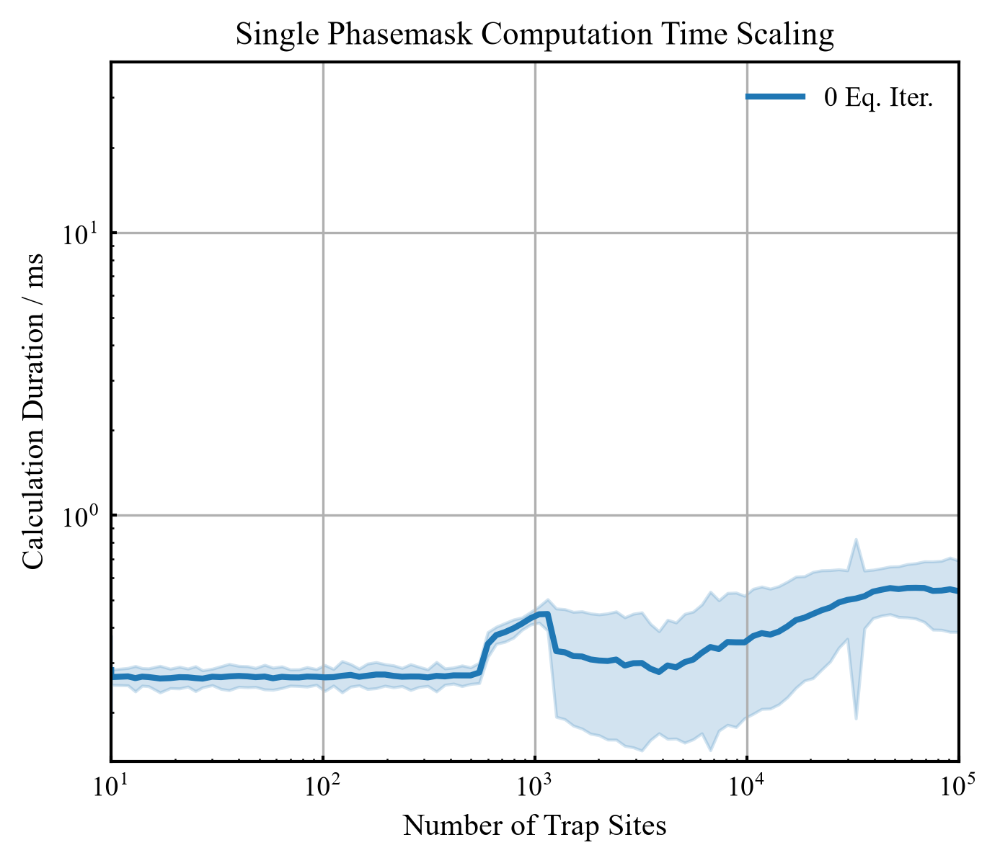

In [23]:
fig, ax = plt.subplots(figsize=(3.37*1.5, 2.8*1.5))

ax.plot(N_traps0, times0, color='C0', linewidth=2.0, label='0 Eq. Iter.')
ax.fill_between(N_traps0, np.array(times0) - np.array(times0_std), np.array(times0) + np.array(times0_std), color='C0', alpha=0.2)

#ax.plot(N_traps1, times1, color='C1', linewidth=2.0, label='1 Eq. Iter.')
#ax.fill_between(N_traps1, np.array(times1) - np.array(times1_std), np.array(times1) + np.array(times1_std), color='C1', alpha=0.2)

#ax.plot(N_traps2, times2, color='C2', linewidth=2.0, label='2 Eq. Iter.')
#ax.fill_between(N_traps2, np.array(times2) - np.array(times2_std), np.array(times2) + np.array(times2_std), color='C2', alpha=0.2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=50))
ax.xaxis.set_minor_formatter(NullFormatter()) # Hides minor tick text

# Format axes
ax.set_xlabel("Number of Trap Sites")
ax.set_ylabel("Calculation Duration / ms")
ax.set_title('Single Phasemask Computation Time Scaling')

#ax.hlines([0.705], 0, 2E5, linestyle='--', color='C3', label="SLM phase mask\nupload time = 0.705 ms")
#ax.vlines([2205], 0, 40, linestyle='--', color='gray', label="$N_{{traps}} = 2205$")
ax.set_xlim(10, 1E5)
ax.set_ylim(0, 40)
ax.grid()
ax.legend()

#plt.savefig("Images\\single_phasemask_calc_scaling.png", bbox_inches='tight')